# Does flattening the seed template's surround help at K = 10? -- 49 ROIs x **6** clicks, four keep-regions, post-D11

**Why this run exists.** Three earlier runs asked whether flattening the surround of the seed template helps, all
at **3 clicks per ROI**. At K = 20 and K = 30 the answer resolved. At **K = 10 it never did** -- and not because
the effect is absent, but because the measurement is too coarse there. A ROI's TP@10 summed over 3 clicks is out
of 30, so one detection moves that ROI by 3.3 points and ROIs tie constantly. In the most recent run
(`shape_vs_mass_template_terms_49roi_3seed`), `hem_rect_fill - default_51` at K = 10 was **+2.45 points,
bootstrap CI [+0.48, +4.69]** at `tm_score` -- the largest point estimate of any K -- yet **17 of 49 ROIs tied**,
only 21 moved in the delta's direction, and Holm came out at 0.124. At `chromatin_od`, 31 of 49 tied.

K = 10 is the part of the list a pathologist actually reads, so "not resolvable" is not an acceptable resting
place. **This notebook re-runs the comparison with 6 clicks per ROI** so the K = 10 granularity is fine enough to
resolve it. Nothing else about the method changes.

## The four arms

All four cut a **51x51 `hematoxylin_od` window centred on the click**, exactly as production does. Only the pixel
values differ. In every filled arm the fill value is **the mean of the pixels that arm fills**, recomputed per arm
since each keeps a different region.

| arm | kept region | template |
|---|---|---|
| `default_51` | everything | the window, untouched |
| `hem_rect_fill` | `ss.tighten_box_otsu(W)` | pixels outside it set to the mean of those outside pixels |
| `hem_rect_fill_1um` | that rectangle grown by `int(round(1.0 / mpp))` px on every edge, each edge clipped to the 51 px window independently | pixels outside the grown rectangle set to the mean of those outside pixels |
| `hem_mask_fill_1um` | **the accepted Otsu component itself, dilated by the same `margin_px`** -- a non-rectangular mask | pixels outside the dilated mask set to the mean of those outside pixels |

**The last two arms differ only in the corners.** For any structuring element,
`bbox(component + B) == bbox(component) + bbox(B)`, so the bounding rectangle of the dilated component is exactly
`hem_rect_fill_1um`'s rectangle -- Gate 8 asserts that identity on every click. The new arm is therefore **not**
"pad the component then re-box it", which would be a byte-identical no-op. It keeps the **padded mask itself**,
which covers about 72% of that rectangle; the remaining corner was never nucleus. Dropping those corners is the
whole point of the arm, so it isolates keep-region **shape** with the padding and the bounding geometry held fixed.

## Clicks: extended to 6 per ROI, not redrawn

The clicks come from `rerun_bbox3way_postD11.select_clicks`, the recorded runs' own joint-gate procedure --
`rng = np.random.default_rng([seed_index, image_id])` over the agreement-tier, border-filtered mitotic pool,
removing each accepted annotation before the next draw, accepting only candidates where **both** the
`gray_inverted` and `hematoxylin_od` Otsu boxes succeed and the resulting centre has a readable 73 px patch.
`SEED_INDICES` is extended from `(0, 1, 2)` to `(0, 1, 2, 3, 4, 5)`. Because each seed has its own RNG stream and
the pool shrinks only by the accepted annotations, **seeds 0-2 reproduce the recorded clicks exactly** and seeds
3-5 are new. Gate 1 asserts that on all 49 ROIs before anything else runs.

**Six is the largest balanced choice.** The joint-valid pool per ROI is min 6, median 18, max 162: all 49 ROIs
have at least 6, but only 42 have 9 and 37 have 12. Going past 6 would either drop ROIs -- changing the
population and forfeiting comparability with every recorded run -- or make the design unbalanced, so that ROIs
carry different weights and the ROI-level exact sign-flip no longer assumes a common per-ROI scale.

## Both ranking axes, from one search

Measured at `rank_key = "chromatin_od"` and `rank_key = "tm_score"`. These are **two different outcomes, not two
looks at one**, so each gets its own Holm family. The template search, peak extraction, NMS and D11 blanking run
**once** per (click, arm) and the two axes differ only in the final sort key (`production.AXES` maps
`tm_score -> score`, `chromatin_od -> od`). The axis comparison is therefore exact by construction, and Gate 7
asserts that the two rankings are permutations of the same `(cx, cy, score, od)` rows on every run.

`tm_score` is the cleaner axis here and carries the headline: the mass term in these templates is nearly the same
statistic as the `chromatin_od` ranker, so that axis flatters any arm that carries one.

## Budget

**Only K = 10 is tested.** Every hypothesis test, Holm family and D5 verdict is at K = 10 alone. TP@20 and TP@30
are recorded in the per-run CSV as free descriptive columns and appear in no family and in no verdict.

## Held identical across arms

- the 294 clicks (49 ROIs x 6), in a fixed order;
- window position (centred on the click) and template size (51 px), so `tm.blank_seed_square` blanks the **same**
  51x51 square in every arm and no base-size confound enters;
- search image (`hematoxylin_od`, D11-blanked then replicate-padded by 25 px);
- `PEAK_MIN_DISTANCE` 7, `DEEP_FLOOR_Z` -1.5, `MAX_PEAKS` 100, NMS radius = match radius = `ev.radius_px(mpp)`;
- the `chromatin_od` window (51 px), scored against the **unblanked** channel;
- greedy centre-distance matching at 7.5 um with the click's own annotation removed from the ground truth;
- a fixed K, since each arm's peak threshold comes from its own response map and list lengths can differ.

## D11

D11 (commit `9e22eb9`) replaced the 5 px post-NMS self-hit filter with `tm.blank_seed_square`, which blanks the
seed's own template footprint from a **copy** of the search channel before correlation; `production.SELF_HIT_RADIUS`
no longer exists. The recorded `hemrectfill` and `hemrectfill1um` runs are **pre-D11**; `bbox3way_postD11` and
`fillalpha_postD11` are post-D11. D11 changed outcomes but **not** templates, so template-level gates still work
against the pre-D11 runs even though detection-level ones do not. This run is post-D11.

## Gates, all before any statistic is read

1. **Click reproduction.** Seeds 0-2 match the recorded `seed_ann_id`/`click_cx`/`click_cy` on all 49 ROIs.
2. **Harness fidelity, pre-D11, subset.** On 2 ROIs x 3 clicks the inlined pipeline, run in pre-D11 mode (no
   blanking, plus a 5.0 px post-NMS self-hit filter at the click), reproduces the recorded `bbox3way`
   `default_51` and `hemrectfill` `hem_rect_fill` runs bit for bit.
3. **Production-path equivalence, post-D11, subset.** The post-D11 `default_51` path equals
   `prod.run_production_pipeline` row for row at **both** axes.
4. **Cross-notebook parity, seeds 0-2, full run, `chromatin_od`.** `default_51` reproduces `bbox3way_postD11`, and
   `hem_rect_fill` reproduces the `fill_alpha_1` arm of `fillalpha_postD11` -- counts, TP@10/20/30, template
   SHA-1, and the top-30 rank/cx/cy/bucket/matched_ann_id/score/od.
5. **Template parity for the 1 um arm, seeds 0-2.** The grown rectangle and its fill equal `rectm_*` and
   `fill_value_1um` in the recorded `hemrectfill1um_clicks.csv`; the tight rectangle and its fill equal `rect_*`
   and `fill_value` in `hemrectfill_clicks.csv`.
6. **Margin geometry, all clicks.** Each edge grows by `min(margin_px, room to that border)` and no more; the
   grown rectangle never leaves the window; the filled pixel count equals `2601 - h * w`. Template distinctness is
   **reported rather than asserted** -- see the boundary case below.
7. **One detection set per (click, arm).** The two axes' rankings are permutations of the same rows.
8. **The mask arm, which has no external reference of any kind.** The re-derived component's `regionprops` bbox
   equals `ss.tighten_box_otsu(W)`; the dilated mask's bounding box equals `hem_rect_fill_1um`'s grown rectangle
   **exactly**; the mask is a strict subset of that rectangle with strictly fewer kept pixels; the fill equals the
   mean of the pixels outside the mask; and all four arms' SHA-1s are distinct.

`score` is stored at float32 repr in the recorded CSVs, so it is compared after a `np.float32` cast; `od` is
stored at full precision and compares at `rtol = 1e-12`.

### One boundary case, and the assumption taken

Extending the draw to 6 clicks reaches clicks the 3-click runs never drew, and some of them have an Otsu
rectangle so large that growing it by `margin_px` on every edge **covers the whole 51 px window**. There is then
nothing outside to fill, and that arm's template is byte-identical to `default_51`.

That is not a bug: it is the arm's own definition -- "the rectangle grown by `int(round(1.0 / mpp))` px on every
edge, each edge clipped to the window" -- evaluated where there is no room left to grow into. Every alternative
breaks something the design insists on: dropping the ROI changes the population, dropping the click unbalances
the per-ROI scale the exact sign-flip assumes, redrawing is forbidden, and shrinking the margin per click
redefines the arm. So **the click is kept and the degeneracy is recorded**: `fill_outside` returns the untouched
window with a NaN fill and 0 filled pixels, the clicks CSV carries a `degenerate_<arm>` flag and a
`collided_with_default` column, and `four_distinct_templates` is a **report**-severity verification row rather
than a halt. The run still asserts that a collision happens **only** where the keep region covers the window --
an arm matching `default_51` for any other reason is a construction bug and halts -- and that **no recorded
click (seeds 0-2) is affected**, since the recorded `hemrectfill1um` run executed those same 147 clicks.

The consequence is conservative: such a click contributes a structural 0 to every contrast between that arm and
`default_51`, diluting rather than inflating it. The tie report separates these **structural** zeros -- which no
number of clicks could ever break -- from the granularity ties this run exists to reduce.

## Comparisons, fixed before the run

Every delta is `a - b`; the unit is the **ROI (49)**; a ROI's delta is its **TP@10 summed over its 6 clicks**.
**Each (axis, family) is its own Holm family -- four families, 10 rows in total.**

- *primary, 3 tests per axis* -- the question as posed, our method against the incumbent:
  `hem_rect_fill - default_51`, `hem_rect_fill_1um - default_51`, `hem_mask_fill_1um - default_51`.
- *secondary, 2 tests per axis* -- which ingredient, if any, is doing the work:
  `hem_rect_fill_1um - hem_rect_fill` (does the 1 um margin add anything? at 3 clicks this was K = 10-only:
  +0.75 pts [+0.27, +1.36], but 39 of 49 ROIs tied and D5 was not met) and
  `hem_mask_fill_1um - hem_rect_fill_1um` (does dropping the rectangle's corners add anything? both arms carry
  the same padding and the same bounding geometry, so this isolates keep-region shape alone).

Per pair: the pooled precision delta with a cluster bootstrap 95% CI over ROIs (`BOOT_SEED` 20260917,
`N_BOOT` 10000, the same ROI order as every earlier run, asserted), a t interval over the ROI-level deltas,
ROI-level W/L/T, `n_nonzero`, `min_attainable_p`, an exact sign-flip p by convolution, Holm within family, and the
D5 bar (bootstrap CI excludes 0 **and** a majority of all 49 ROIs move in the delta's direction).

### Reading rules, fixed before the run

- CI excludes 0, delta > 0: `a` has higher precision than `b`. CI excludes 0, delta < 0: lower.
- CI includes 0: **no difference detected**; the CI is quoted as the bound. **No equivalence is claimed.**
- Every verdict is stated with its t CI, exact p, Holm p, ROI W/L/T, `n_nonzero` and D5 bar alongside -- never a
  CI on its own.
- Ties bound what can be shown: precision@10 moves in steps of `1/60` per ROI, the exact sign-flip p cannot fall
  below `2 ** (1 - n_nonzero)`, and any row whose Holm-adjusted floor exceeds 0.05 could not have reached
  significance at any effect size. Such a row **bounds nothing and is not a null**, and is flagged as such.
- The two axes rank the same detections. A result on one is **not** a replication of the other.

If 6 clicks still leaves K = 10 unresolved, that is reported with the tie counts. It is not escalated to more
clicks, a different gate, or extra budgets here.

In [1]:
import gc
import hashlib
import itertools
import math
import os
import sys
import time
import types
from fractions import Fraction

import cv2
import numpy as np
import pandas as pd
from scipy import stats as sps
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

sys.path.insert(0, '..')
from midog_utils import channels as ch
from midog_utils import chromatin as cm
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import invariants as inv
from midog_utils import production as prod
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance
import rerun_bbox3way_postD11 as rr    # the recorded runs' own joint-gate click selection, reused verbatim

pd.set_option('display.width', 250)
pd.set_option('display.max_columns', 80)
pd.set_option('display.max_rows', 400)
pd.set_option('display.max_colwidth', 140)

NB_T0 = time.time()

REFERENCE_CONFIG = dict(CHANNEL='hematoxylin_od', TM_METHOD=cv2.TM_CCOEFF, PEAK_MIN_DISTANCE=7, DEEP_FLOOR_Z=-1.5, MAX_PEAKS=100, OD_WINDOW=51)
CONFIG_DRIFT = pd.DataFrame([dict(setting=k, production_py=getattr(prod, k), reference_notebook=v, match=getattr(prod, k) == v) for k, v in REFERENCE_CONFIG.items()])
print(CONFIG_DRIFT.to_string(index=False))
assert CONFIG_DRIFT['match'].all(), 'midog_utils.production no longer matches the configuration the recorded runs used'
assert ev.MIDOG_RADIUS_UM == 7.5, 'D7: NMS radius = match radius = 7.5 um'
assert (tm.BASE_SIZE, tm.PATCH_SIZE) == (51, 73), 'the template and patch sizes this notebook hard-codes'
assert prod.OD_WINDOW // 2 == 25, 'the replicate pad this notebook hard-codes is 25 px'
assert hasattr(tm, 'blank_seed_square'), 'D11 has not been applied: template_match.blank_seed_square is missing'
assert not hasattr(prod, 'SELF_HIT_RADIUS'), 'production.SELF_HIT_RADIUS still exists, so this is not post-D11 code'
assert set(prod.AXES) == {'tm_score', 'chromatin_od'}, f'production.AXES changed: {prod.AXES}'

SMOKE_ROIS = None              # None = all 49 ROIs; a smoke run names a few ROI file names
PRE_D11_SELF_HIT_RADIUS = 5.0  # the constant D11 deleted, kept only to replay the pre-D11 gate
PAD = prod.OD_WINDOW // 2      # 25
BASE_SIZE = tm.BASE_SIZE       # 51
MARGIN_UM = 1.0

ARMS = ('default_51', 'hem_rect_fill', 'hem_rect_fill_1um', 'hem_mask_fill_1um')
ARM_KEEP = {'default_51': 'the whole window', 'hem_rect_fill': 'the Otsu rectangle', 'hem_rect_fill_1um': 'that rectangle + 1 um', 'hem_mask_fill_1um': 'the Otsu component + 1 um'}
RECT_ARMS = ('hem_rect_fill', 'hem_rect_fill_1um')     # the two arms with a recorded rectangle and fill value
MASK_ARM = 'hem_mask_fill_1um'                          # no recorded reference of any kind
AXES = ('chromatin_od', 'tm_score')
AXIS_KEY = {'chromatin_od': 'od', 'tm_score': 'score'}  # production.AXES, restated so drift is visible
assert AXIS_KEY == prod.AXES, f'this notebook and production.AXES disagree: {AXIS_KEY} vs {prod.AXES}'

BUDGETS = (10, 20, 30)         # recorded descriptively in per_run; only TEST_K is ever tested
TEST_K = 10                    # every hypothesis test, Holm family and D5 verdict is at K = 10 alone
assert TEST_K in BUDGETS, 'the tested budget must also be recorded'
SEED_INDICES = (0, 1, 2, 3, 4, 5)
RECORDED_SEEDS = (0, 1, 2)     # the seeds the recorded 3-click runs drew, which must reproduce exactly
N_CLICKS_PER_ROI = len(SEED_INDICES)
N_BOOT = 10_000
BOOT_SEED = 20260917           # every earlier run's seed; with the same ROI order the resampled ROI sets are the same ones

FAMILY_PAIRS = {
    'primary_3': (('hem_rect_fill', 'default_51'), ('hem_rect_fill_1um', 'default_51'), ('hem_mask_fill_1um', 'default_51')),
    'secondary_2': (('hem_rect_fill_1um', 'hem_rect_fill'), ('hem_mask_fill_1um', 'hem_rect_fill_1um')),
}
PAIRS = tuple(pair for pairs in FAMILY_PAIRS.values() for pair in pairs)
PAIR_FAMILY = {f'{a} - {b}': fam for fam, pairs in FAMILY_PAIRS.items() for a, b in pairs}
assert len(PAIR_FAMILY) == len(PAIRS) == 5, 'a pair appears in two families, or the pair list changed'

B3 = '../results/precision_at_k_49roi_3seed_chromatin_bbox3way'
B3P = f'{B3}_postD11'
HRF = '../results/precision_at_k_49roi_3seed_chromatin_hemrectfill'
HRF1 = f'{HRF}1um'
FA = '../results/precision_at_k_49roi_3seed_chromatin_fillalpha_postD11'
SM = '../results/precision_at_k_49roi_3seed_shapemass_postD11'
SUBSET_DIRS = {'original_14': '../images/extra_valid', 'testing_35': '../images/extra_valid/testing_set'}
INSPECT_ROI = '300.tiff'
N_GATE_ROIS = 2

SUFFIX = '' if SMOKE_ROIS is None else '_smoke'
OUT_STEM = f'../results/precision_at_k_49roi_6seed_fillgeom_postD11{SUFFIX}'
OUT = {name: f'{OUT_STEM}_{name}.csv' for name in ('clicks', 'per_run', 'top30', 'per_roi', 'delta_per_roi', 'delta_stats', 'verification')}
FIG_PATHS = {name: f'fillgeom6_{name}{SUFFIX}.png' for name in ('templates', 'precision', 'granularity')}
RECORDED_STEMS = (B3, B3P, HRF, HRF1, FA, SM, '../results/precision_at_k_14roi_')
assert not any(p.startswith(stem) for p in OUT.values() for stem in RECORDED_STEMS), 'an output path would overwrite a recorded run'

# Okabe-Ito, the published colourblind-safe qualitative set; fixed order, one hue per arm, never cycled.
ARM_COLOR = {'default_51': '#666666', 'hem_rect_fill': '#E69F00', 'hem_rect_fill_1um': '#0072B2', 'hem_mask_fill_1um': '#009E73'}

print(f"\narms {ARMS}; ranking axes {AXES}; K recorded {BUDGETS}, K tested {TEST_K} only")
print(f"clicks: {N_CLICKS_PER_ROI} per ROI, seeds {SEED_INDICES} (seeds {RECORDED_SEEDS} must reproduce the recorded draw)")
print(f"cluster bootstrap B = {N_BOOT} (seed {BOOT_SEED}); smoke ROIs = {SMOKE_ROIS}")
for fam, pairs in FAMILY_PAIRS.items():
    print(f"  {fam} (its own Holm family per axis): {[f'{a} - {b}' for a, b in pairs]}")
print('outputs:', *OUT.values(), *FIG_PATHS.values(), sep='\n  ')

          setting  production_py reference_notebook  match
          CHANNEL hematoxylin_od     hematoxylin_od   True
        TM_METHOD              4                  4   True
PEAK_MIN_DISTANCE              7                  7   True
     DEEP_FLOOR_Z           -1.5               -1.5   True
        MAX_PEAKS            100                100   True
        OD_WINDOW             51                 51   True

arms ('default_51', 'hem_rect_fill', 'hem_rect_fill_1um', 'hem_mask_fill_1um'); ranking axes ('chromatin_od', 'tm_score'); K recorded (10, 20, 30), K tested 10 only
clicks: 6 per ROI, seeds (0, 1, 2, 3, 4, 5) (seeds (0, 1, 2) must reproduce the recorded draw)
cluster bootstrap B = 10000 (seed 20260917); smoke ROIs = None
  primary_3 (its own Holm family per axis): ['hem_rect_fill - default_51', 'hem_rect_fill_1um - default_51', 'hem_mask_fill_1um - default_51']
  secondary_2 (its own Holm family per axis): ['hem_rect_fill_1um - hem_rect_fill', 'hem_mask_fill_1um - hem_rect_fill_1

In [2]:
B3P_RUN = pd.read_csv(f'{B3P}_per_run.csv', float_precision='round_trip')
B3P_TOP = pd.read_csv(f'{B3P}_top30.csv', float_precision='round_trip')
B3_RUN = pd.read_csv(f'{B3}_per_run.csv', float_precision='round_trip')
B3_TOP = pd.read_csv(f'{B3}_top30.csv', float_precision='round_trip')
HRF_RUN = pd.read_csv(f'{HRF}_per_run.csv', float_precision='round_trip')
HRF_TOP = pd.read_csv(f'{HRF}_top30.csv', float_precision='round_trip')
HRF_CLICKS = pd.read_csv(f'{HRF}_clicks.csv', float_precision='round_trip')
HRF1_CLICKS = pd.read_csv(f'{HRF1}_clicks.csv', float_precision='round_trip')
FA_RUN = pd.read_csv(f'{FA}_per_run.csv', float_precision='round_trip')
FA_TOP = pd.read_csv(f'{FA}_top30.csv', float_precision='round_trip')
SM_STATS = pd.read_csv(f'{SM}_delta_stats.csv', float_precision='round_trip')
HRF1_STATS = pd.read_csv(f'{HRF1}_delta_stats.csv', float_precision='round_trip')
assert (len(B3P_RUN), len(FA_RUN), len(HRF_RUN), len(HRF_CLICKS), len(HRF1_CLICKS)) == (441, 735, 294, 147, 147), 'a recorded input does not have its expected row count'
for name, frame in (('B3P_TOP', B3P_TOP), ('FA_TOP', FA_TOP), ('B3_TOP', B3_TOP), ('HRF_TOP', HRF_TOP)):
    assert {'rank', 'cx', 'cy', 'score', 'od', 'bucket', 'matched_ann_id', 'file_name', 'seed_index', 'condition'} <= set(frame.columns), f'{name} is missing a column the parity gate compares'

# post-D11 parity targets (Gate 4): default_51 from the bbox3way re-run, hem_rect_fill from the fill-alpha sweep's alpha = 1 arm
POST_ARM_OF = {'default_51': ('default_51', B3P_RUN, B3P_TOP), 'hem_rect_fill': ('fill_alpha_1', FA_RUN, FA_TOP)}
POST_RUN, POST_TOP = {}, {}
for arm, (rec_arm, run_ref, top_ref) in POST_ARM_OF.items():
    POST_RUN[arm] = run_ref[run_ref['condition'] == rec_arm].set_index(['file_name', 'seed_index']).sort_index()
    POST_TOP[arm] = {key: g for key, g in top_ref[top_ref['condition'] == rec_arm].groupby(['file_name', 'seed_index'])}
    assert POST_RUN[arm].index.is_unique and len(POST_RUN[arm]) == 147 and len(POST_TOP[arm]) == 147, f'{arm}: the post-D11 reference is not one row and one top-30 list per recorded click'
    assert all(len(g) == 30 for g in POST_TOP[arm].values()), f'{arm}: a recorded top-30 list does not have 30 rows'

# pre-D11 references (Gate 2), used only by the harness-fidelity replay
PRE_ARM_OF = {'default_51': 'default_51', 'hem_rect_fill': 'hem_rect_fill'}
PRE_RUN = pd.concat([B3_RUN[B3_RUN['condition'] == 'default_51'], HRF_RUN[HRF_RUN['condition'] == 'hem_rect_fill']]).set_index(['file_name', 'seed_index', 'condition']).sort_index()
PRE_TOP = {key: g for key, g in pd.concat([B3_TOP[B3_TOP['condition'] == 'default_51'], HRF_TOP[HRF_TOP['condition'] == 'hem_rect_fill']]).groupby(['file_name', 'seed_index', 'condition'])}

# recorded template geometry (Gate 5): the tight rectangle and fill, and the grown rectangle and fill, on the recorded clicks
REC_GEOM = HRF_CLICKS[['file_name', 'seed_index', 'rect_y0', 'rect_y1', 'rect_x0', 'rect_x1', 'n_filled_px', 'fill_value']].merge(
    HRF1_CLICKS[['file_name', 'seed_index', 'margin_px', 'rectm_y0', 'rectm_y1', 'rectm_x0', 'rectm_x1', 'n_filled_px_1um', 'fill_value_1um']], on=['file_name', 'seed_index'], how='outer', validate='one_to_one').set_index(['file_name', 'seed_index'])
assert len(REC_GEOM) == 147 and REC_GEOM.notna().all().all(), 'the recorded fill geometry is not complete on all 147 recorded clicks'

# the 3-click baselines this run exists to sharpen, read from the recorded stats rather than retyped
BASELINE_3CLICK = pd.concat([
    SM_STATS.loc[(SM_STATS['pair'] == 'fill_alpha_1 - default_51') & (SM_STATS['K'] == TEST_K)].assign(pair='hem_rect_fill - default_51', source='shapemass_postD11 (post-D11)'),
    HRF1_STATS.loc[(HRF1_STATS['pair'] == 'hem_rect_fill_1um - hem_rect_fill') & (HRF1_STATS['K'] == TEST_K)].assign(rank_key='chromatin_od', source='hemrectfill1um (pre-D11)'),
    HRF1_STATS.loc[(HRF1_STATS['pair'] == 'hem_rect_fill_1um - default_51') & (HRF1_STATS['K'] == TEST_K)].assign(rank_key='chromatin_od', source='hemrectfill1um (pre-D11)'),
])[['source', 'rank_key', 'pair', 'K', 'pooled_delta_precision', 'wins', 'losses', 'ties', 'n_nonzero', 'exact_p', 'min_attainable_p', 'ci_low', 'ci_high', 'holm_p', 'd5_bar_met']].reset_index(drop=True)
print(f'the 3-click baselines at K = {TEST_K} this run exists to sharpen:')
print(BASELINE_3CLICK.to_string(index=False, float_format=lambda v: f'{v:.4g}'))

the 3-click baselines at K = 10 this run exists to sharpen:
                      source     rank_key                              pair  K  pooled_delta_precision  wins  losses  ties  n_nonzero  exact_p  min_attainable_p    ci_low  ci_high  holm_p  d5_bar_met
shapemass_postD11 (post-D11) chromatin_od        hem_rect_fill - default_51 10                0.001361     9       9    31         18   0.9221         7.629e-06  -0.01156  0.01497       1       False
shapemass_postD11 (post-D11)     tm_score        hem_rect_fill - default_51 10                 0.02449    21      11    17         32  0.03092         4.657e-10  0.004762  0.04694  0.1237       False
    hemrectfill1um (pre-D11) chromatin_od hem_rect_fill_1um - hem_rect_fill 10                0.007483     9       1    39         10  0.01562          0.001953  0.002721  0.01361 0.09375       False
    hemrectfill1um (pre-D11) chromatin_od    hem_rect_fill_1um - default_51 10                0.009524    14       7    28         21   0.22

## Templates -- the four keep-regions, and the mask arm's own construction

`cut_window` cuts the 51 px window production cuts. `otsu_component` re-derives the component
`ss.tighten_box_otsu` accepts, using that function's own internals, so the mask arm keeps the region the
production gate actually selected rather than a re-derivation of it. `fill_outside` takes a boolean **keep mask**,
not a rectangle, so all three filled arms share one fill rule: `mean(outside)` computed in float64 and cast to
float32, exactly as the recorded runs computed it.

In [3]:
def cut_window(hem, cx, cy):
    """
        The 51 px template production cuts for a click, and the identical Otsu window, checked against each other.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.

        Returns np.ndarray: the 51x51 float32 template, exactly as build_augmentations produces it.
    """
    patch = tm.read_padded_patch(hem, cx, cy, tm.PATCH_SIZE)
    assert patch is not None, f'({cx}, {cy}): the 73 px patch is not readable'
    templates, _ = tm.build_augmentations(patch, BASE_SIZE, (1.0,), 1, (False,))
    T = templates[0]
    assert T.shape == (BASE_SIZE, BASE_SIZE) and T.dtype == np.float32, f'({cx}, {cy}): template is {T.shape} {T.dtype}'
    W = tm.read_padded_patch(hem, cx, cy, BASE_SIZE)
    assert np.array_equal(W, T), f'({cx}, {cy}): the Otsu window and the template are not the same pixels'
    return T


def otsu_component(W):
    """
        The connected component tighten_box_otsu accepts, re-derived with that function's own internals.

        W (np.ndarray): the 51x51 float32 window, the same pixels as the template.

        Returns tuple[np.ndarray, tuple[int, int, int, int]]: the component's boolean mask and its regionprops bbox as (y0, y1, x0, x1).
    """
    u8 = cv2.normalize(W.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    centre_label = int(labels[BASE_SIZE // 2, BASE_SIZE // 2])
    assert centre_label != 0, 'the window centre is not foreground, so tighten_box_otsu would have refused this click'
    region = next(p for p in regionprops(labels) if p.label == centre_label)
    y0, x0, y1, x1 = region.bbox    # skimage bbox order is (min_row, min_col, max_row, max_col)
    return labels == centre_label, (int(y0), int(y1), int(x0), int(x1))


def margin_rect(rect, margin_px):
    """
        A half-open template-local rectangle grown by margin_px on every edge, each edge clipped to the 51 px window on its own.

        rect (tuple[int, int, int, int]): (y0, y1, x0, x1), half-open, template-local.
        margin_px (int): pixels added on every edge before clipping.

        Returns tuple[int, int, int, int]: the grown rectangle (y0, y1, x0, x1), inside [0, 51].
    """
    y0, y1, x0, x1 = rect
    return max(0, y0 - margin_px), min(BASE_SIZE, y1 + margin_px), max(0, x0 - margin_px), min(BASE_SIZE, x1 + margin_px)


def rect_mask(rect):
    """
        The boolean keep mask of a half-open template-local rectangle.

        rect (tuple[int, int, int, int]): (y0, y1, x0, x1), half-open, template-local.

        Returns np.ndarray: a 51x51 boolean mask, True inside the rectangle.
    """
    y0, y1, x0, x1 = rect
    keep = np.zeros((BASE_SIZE, BASE_SIZE), bool)
    keep[y0:y1, x0:x1] = True
    return keep


def mask_bbox(mask):
    """
        The half-open bounding rectangle of a boolean mask.

        mask (np.ndarray): a 51x51 boolean mask with at least one True pixel.

        Returns tuple[int, int, int, int]: (y0, y1, x0, x1), half-open, template-local.
    """
    rows, cols = np.flatnonzero(mask.any(axis=1)), np.flatnonzero(mask.any(axis=0))
    assert len(rows) and len(cols), 'an empty mask has no bounding box'
    return int(rows[0]), int(rows[-1]) + 1, int(cols[0]), int(cols[-1]) + 1


def dilate_mask(mask, margin_px):
    """
        A boolean mask dilated by an elliptical structuring element of radius margin_px, clipped to the window.

        mask (np.ndarray): the 51x51 boolean component mask.
        margin_px (int): the dilation radius in pixels.

        Returns np.ndarray: the dilated 51x51 boolean mask.
    """
    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2 * margin_px + 1, 2 * margin_px + 1))
    return cv2.dilate(mask.astype(np.uint8), se).astype(bool)


def fill_outside(T, keep):
    """
        The template with every pixel outside a keep mask set to the mean of those outside pixels.

        T (np.ndarray): the 51x51 float32 template.
        keep (np.ndarray): the 51x51 boolean keep mask; the pixels this arm leaves untouched.

        Returns tuple[np.ndarray, np.float32, int]: the filled template, the fill value, and the number of filled pixels; a keep mask covering the whole window returns the untouched template, NaN and 0.
    """
    outside = ~keep
    if not outside.any():
        # the keep region covers the whole window: "fill outside it" is vacuous and this arm's template IS the untouched
        # window. That is the arm's own definition evaluated at its boundary, so it is recorded, not treated as an error.
        return np.ascontiguousarray(T, dtype=np.float32), np.float32(np.nan), 0
    fill = np.float32(T[outside].astype(np.float64).mean())   # float64 mean then cast, exactly as the recorded runs computed it
    F = T.copy()
    F[outside] = fill
    F = np.ascontiguousarray(F, dtype=np.float32)
    assert np.array_equal(F[keep], T[keep]) and (F[outside] == fill).all(), 'the fill changed a kept pixel or missed a filled one'
    return F, fill, int(outside.sum())


def template_sha1(T):
    """
        SHA-1 of a template's float32 bytes, the digest the recorded runs store as tpl_sha1.

        T (np.ndarray): the 51x51 float32 template.

        Returns str: the hex digest.
    """
    return hashlib.sha1(np.ascontiguousarray(T, dtype=np.float32).tobytes()).hexdigest()


def cut_templates(hem, cx, cy, margin_px):
    """
        The four arms' templates for one click, all cut from the same 51 px window so the arms differ only in what they keep.

        hem (np.ndarray): this ROI's hematoxylin_od channel.
        cx (float): click x, full-image pixels.
        cy (float): click y, full-image pixels.
        margin_px (int): pixels of margin the two 1 um arms add.

        Returns dict: templates (arm -> 51x51 float32), keeps, rect, rect_m, comp_bbox, mask_bbox_m, fills, kept and filled pixel counts.
    """
    T = cut_window(hem, cx, cy)
    rect = ss.tighten_box_otsu(T)
    assert rect is not None, f'({cx}, {cy}): tighten_box_otsu refused the window'
    comp, comp_bbox = otsu_component(T)
    # Gate 8a -- the re-derived component is the one production's gate accepts, not a look-alike
    assert comp_bbox == rect, f'({cx}, {cy}): the re-derived component bbox {comp_bbox} is not tighten_box_otsu {rect}'

    rect_m = margin_rect(rect, margin_px)
    mask_m = dilate_mask(comp, margin_px)
    keeps = {'default_51': np.ones((BASE_SIZE, BASE_SIZE), bool), 'hem_rect_fill': rect_mask(rect), 'hem_rect_fill_1um': rect_mask(rect_m), MASK_ARM: mask_m}

    templates, fills, n_filled = {'default_51': np.ascontiguousarray(T, dtype=np.float32)}, {'default_51': np.float32(np.nan)}, {'default_51': 0}
    for arm in ARMS[1:]:
        templates[arm], fills[arm], n_filled[arm] = fill_outside(T, keeps[arm])
    degenerate = {arm: n_filled[arm] == 0 for arm in ARMS[1:]}   # an arm whose keep region covers the window reduces to default_51
    return dict(templates=templates, keeps=keeps, fills=fills, n_filled=n_filled, degenerate=degenerate, rect=rect, rect_m=rect_m, comp_bbox=comp_bbox,
                mask_bbox_m=mask_bbox(mask_m), n_comp_px=int(comp.sum()), n_kept=({arm: int(keeps[arm].sum()) for arm in ARMS}), margin_px=margin_px)


def geometry_gates(tag, cut, T):
    """
        Gates 6 and 8 for one click: margin growth, window containment, filled-pixel arithmetic, the mask identity and the four distinct templates.

        tag (str): names the click in assertion messages.
        cut (dict): the click's cut_templates output.
        T (np.ndarray): the 51x51 float32 window, for re-deriving the fills independently.

        Returns dict: the click's geometry record, including the mask's share of its bounding rectangle.
    """
    y0, y1, x0, x1 = cut['rect']
    my0, my1, mx0, mx1 = cut['rect_m']
    m = cut['margin_px']
    grew = dict(grow_top=y0 - my0, grow_bottom=my1 - y1, grow_left=x0 - mx0, grow_right=mx1 - x1)
    room = dict(grow_top=min(m, y0), grow_bottom=min(m, BASE_SIZE - y1), grow_left=min(m, x0), grow_right=min(m, BASE_SIZE - x1))
    # Gate 6 -- each edge grows by min(margin, room to that border) and no more, and the grown rectangle stays inside the window
    assert grew == room, f'{tag}: the margin grew by {grew}, not min(margin, room) = {room}'
    assert 0 <= my0 < my1 <= BASE_SIZE and 0 <= mx0 < mx1 <= BASE_SIZE, f'{tag}: the grown rectangle {cut["rect_m"]} leaves the {BASE_SIZE} px window'
    for arm, rect in (('hem_rect_fill', cut['rect']), ('hem_rect_fill_1um', cut['rect_m'])):
        ry0, ry1, rx0, rx1 = rect
        assert cut['n_filled'][arm] == BASE_SIZE ** 2 - (ry1 - ry0) * (rx1 - rx0), f'{tag} {arm}: {cut["n_filled"][arm]} filled pixels, expected {BASE_SIZE ** 2 - (ry1 - ry0) * (rx1 - rx0)}'

    # Gate 8 -- the mask arm, which has no external reference: bbox identity, strict subset, and its own fill
    rect_m_keep = cut['keeps']['hem_rect_fill_1um']
    mask_keep = cut['keeps'][MASK_ARM]
    assert cut['mask_bbox_m'] == cut['rect_m'], f'{tag}: the dilated mask bbox {cut["mask_bbox_m"]} is not the grown rectangle {cut["rect_m"]}, so the two 1 um arms do not share a bounding geometry'
    assert (mask_keep & ~rect_m_keep).sum() == 0, f'{tag}: the dilated mask leaves its own bounding rectangle'
    assert cut['n_kept'][MASK_ARM] < cut['n_kept']['hem_rect_fill_1um'], f'{tag}: the dilated mask keeps {cut["n_kept"][MASK_ARM]} px, not strictly fewer than the rectangle\'s {cut["n_kept"]["hem_rect_fill_1um"]} -- it has no corners to drop and the arm would measure nothing'
    if not cut['degenerate'][MASK_ARM]:
        assert np.float32(T[~mask_keep].astype(np.float64).mean()) == cut['fills'][MASK_ARM], f'{tag}: the mask arm\'s fill is not the mean of the pixels outside the mask'

    # Template distinctness is a claim about the DATA, not about the construction: an arm whose keep region covers the
    # window is byte-identical to default_51 by its own definition. It is recorded per click and reported, not asserted.
    sha = {arm: template_sha1(cut['templates'][arm]) for arm in ARMS}
    collided = sorted(arm for arm in ARMS[1:] if sha[arm] == sha['default_51'])
    assert collided == sorted(arm for arm in ARMS[1:] if cut['degenerate'][arm]), f'{tag}: an arm matches default_51 without its keep region covering the window, which is a construction bug, not a boundary case ({sha})'
    return dict(margin_px=m, rect_y0=y0, rect_y1=y1, rect_x0=x0, rect_x1=x1, rect_h=y1 - y0, rect_w=x1 - x0,
                rectm_y0=my0, rectm_y1=my1, rectm_x0=mx0, rectm_x1=mx1, rectm_h=my1 - my0, rectm_w=mx1 - mx0, **grew,
                rect_touches_window_edge=bool(y0 == 0 or x0 == 0 or y1 == BASE_SIZE or x1 == BASE_SIZE),
                n_comp_px=cut['n_comp_px'], n_kept_px_rect=cut['n_kept']['hem_rect_fill'], n_kept_px_rectm=cut['n_kept']['hem_rect_fill_1um'], n_kept_px_mask=cut['n_kept'][MASK_ARM],
                mask_share_of_bbox=cut['n_kept'][MASK_ARM] / cut['n_kept']['hem_rect_fill_1um'],
                n_filled_px=cut['n_filled']['hem_rect_fill'], n_filled_px_1um=cut['n_filled']['hem_rect_fill_1um'], n_filled_px_mask=cut['n_filled'][MASK_ARM],
                fill_value=float(cut['fills']['hem_rect_fill']), fill_value_1um=float(cut['fills']['hem_rect_fill_1um']), fill_value_mask=float(cut['fills'][MASK_ARM]),
                n_distinct_templates=len(set(sha.values())), collided_with_default=';'.join(collided),
                **{f'degenerate_{arm}': bool(cut['degenerate'][arm]) for arm in ARMS[1:]}, **{f'sha_{arm}': sha[arm] for arm in ARMS})

## The pipeline, inlined once so both ranking axes can sort the same detections

`search_once` stops before the ranking sort. `rank_by` applies one axis to that list. Everything before the sort
-- correlation, robust threshold, peak extraction, NMS, D11 blanking -- happens **once** per (click, arm), so the
two axes are exact permutations of one detection set rather than two searches (Gate 7). Passing a
`self_hit_radius` instead of a blanked search channel replays the pre-D11 path, which is all Gate 2 needs.

In [4]:
def padded(channel, pad=PAD):
    """
        A channel replicate-padded on every side, the way find_and_suppress pads when border_pad is set.

        channel (np.ndarray): the channel to pad.
        pad (int): pixels added on every side.

        Returns np.ndarray: the padded channel.
    """
    return cv2.copyMakeBorder(channel, pad, pad, pad, pad, borderType=cv2.BORDER_REPLICATE)


def blanked_search(hem, cx, cy, base_size=BASE_SIZE):
    """
        D11's search channel for one click: the seed's own template footprint blanked from a copy, then padded.

        hem (np.ndarray): this ROI's hematoxylin_od channel; never mutated.
        cx (float): template centre x, the click.
        cy (float): template centre y, the click.
        base_size (int): the blanked square's side, 51 for every arm here.

        Returns tuple[np.ndarray, int]: the blanked, padded search channel and the number of pixels blanked.
    """
    search, n_blanked = tm.blank_seed_square(hem, cx, cy, base_size)
    return padded(search), int(n_blanked)


def search_once(match_padded, od_padded, shape, template, cx, cy, nms_radius, self_hit_radius=None):
    """
        One template's search over the ROI, stopping before the ranking sort so both axes can rank the SAME detections.

        match_padded (np.ndarray): the search channel to correlate against, padded by PAD; D11-blanked for the real run, unblanked for the pre-D11 gate.
        od_padded (np.ndarray): the UNBLANKED hematoxylin_od channel padded by PAD, used only for chromatin_od scoring.
        shape (tuple): the unpadded channel's (height, width).
        template (np.ndarray): the 51x51 float32 template.
        cx (float): click x, the template centre and the pre-D11 self-hit centre.
        cy (float): click y, the template centre and the pre-D11 self-hit centre.
        nms_radius (float): this ROI's NMS radius in pixels, evaluate.radius_px(mpp).
        self_hit_radius (float or None): None runs the post-D11 path with no self-hit filter; a radius replays the pre-D11 post-NMS filter.

        Returns tuple[pd.DataFrame, dict]: unranked detections (cx, cy, score, od) and the counts n_peaks, n_detections, n_self_hits.
    """
    h, w = shape
    fused_p, best_p, valid_p = tm.fused_response(match_padded, [template], False, method=prod.TM_METHOD)
    fused = fused_p[PAD:PAD + h, PAD:PAD + w]
    valid = valid_p[PAD:PAD + h, PAD:PAD + w]
    assert valid.all(), 'the 25 px pad left part of the ROI unreachable'
    med, mad = tm.robust_stats(fused, valid)
    threshold = med + prod.DEEP_FLOOR_Z * mad
    centers, scores = tm.extract_peaks(fused, valid, prod.PEAK_MIN_DISTANCE, threshold, prod.MAX_PEAKS)
    n_peaks = len(centers)
    keep = nms_by_distance(centers, scores, nms_radius)
    centers, scores = centers[keep], scores[keep]
    n_self_hits = 0
    if self_hit_radius is not None:
        self_hit = np.hypot(centers[:, 0] - float(cx), centers[:, 1] - float(cy)) <= self_hit_radius
        n_self_hits = int(self_hit.sum())
        centers, scores = centers[~self_hit], scores[~self_hit]
    det = pd.DataFrame({'rank': np.arange(len(centers)), 'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
    shifted = det.assign(cx=det['cx'] + PAD, cy=det['cy'] + PAD)
    det = det.assign(od=cm.score_detections(shifted, od_padded, window=prod.OD_WINDOW)['od'].to_numpy())
    return det, {'n_peaks': n_peaks, 'n_detections': len(det), 'n_self_hits': n_self_hits}


def rank_by(det, rank_key):
    """
        One ranking axis applied to a detection list, in run_production_pipeline's own sort order.

        det (pd.DataFrame): the unranked detections from search_once.
        rank_key (str): "chromatin_od" or "tm_score".

        Returns pd.DataFrame: the detections ranked best-first, with rank reassigned.
    """
    out = det.sort_values(AXIS_KEY[rank_key], ascending=False, na_position='last', kind='mergesort').reset_index(drop=True)
    return out.assign(rank=np.arange(len(out)))


def score_top_k(detections, gt_eval, match_radius):
    """
        Match a ranked detection list to ground truth and count true positives in each top-K.

        detections (pd.DataFrame): ranked detections, best first.
        gt_eval (pd.DataFrame): ground truth with the click's own annotation removed.
        match_radius (float): match radius in pixels.

        Returns tuple[pd.DataFrame, dict]: the detections with match buckets added, and K -> true positives in the top K.
    """
    det_out, _ = ev.bucket_detections(detections, gt_eval, match_radius)
    hit = (det_out['bucket'] == ev.HUMAN_CORRECT_LABEL).to_numpy()
    return det_out, {k: int(hit[:k].sum()) for k in BUDGETS}


def parity_gate(tag, out, info, tp, ref_run, ref_top, count_cols):
    """
        Assert that a re-run arm reproduces a recorded run, and count the top-30 od values that match bit for bit.

        tag (str): names the click and arm in assertion messages.
        out (pd.DataFrame): the re-run's scored detections, ranked.
        info (dict): the re-run's counts, keyed as count_cols names them.
        tp (dict): the re-run's K -> true positives.
        ref_run (pd.Series): the recorded per_run row for this click and arm.
        ref_top (pd.DataFrame): the recorded top-30 rows for this click and arm.
        count_cols (tuple[str]): info keys compared against identically-named recorded columns.

        Returns int: the number of top-30 od values equal to the recorded ones bit for bit.
    """
    for c in count_cols:
        assert int(info[c]) == int(ref_run[c]), f'{tag}: {c} {info[c]} != recorded {int(ref_run[c])}'
    for k in BUDGETS:
        assert tp[k] == int(ref_run[f'tp_at_{k}']), f"{tag}: TP@{k} {tp[k]} != recorded {int(ref_run[f'tp_at_{k}'])}"
    ref, top = ref_top.sort_values('rank'), out.head(30)
    assert len(top) == len(ref) == 30, f'{tag}: {len(top)} rows vs {len(ref)} recorded'
    for c in ('rank', 'cx', 'cy', 'bucket', 'matched_ann_id'):
        assert np.array_equal(top[c].to_numpy(), ref[c].to_numpy()), f'{tag}: top-30 {c} differs from the recorded list'
    # score is stored at float32 repr in the recorded CSVs, so it is compared after a float32 cast; od is stored at full precision
    assert np.array_equal(top['score'].to_numpy(), ref['score'].to_numpy().astype(np.float32)), f'{tag}: top-30 float32 score differs from the recorded list'
    assert np.isclose(top['od'].to_numpy(), ref['od'].to_numpy(), rtol=1e-12, atol=0).all(), f'{tag}: top-30 od differs from the recorded list beyond rtol 1e-12'
    return int((top['od'].to_numpy() == ref['od'].to_numpy()).sum())


def same_detection_set(a, b):
    """
        Gate 7's test that two rankings are permutations of one detection set, not two different searches.

        a (pd.DataFrame): one axis's ranked detections.
        b (pd.DataFrame): the other axis's ranked detections.

        Returns bool: True when both hold the same (cx, cy, score, od) rows in some order.
    """
    cols = ['cx', 'cy', 'score', 'od']
    if len(a) != len(b):
        return False
    ka = a[cols].sort_values(cols, kind='mergesort').to_numpy()
    kb = b[cols].sort_values(cols, kind='mergesort').to_numpy()
    return bool(np.array_equal(ka, kb) or np.allclose(ka, kb, rtol=0, atol=0, equal_nan=True))

## Gates 1, 5, 6 and 8 -- the whole click set, before a single search runs

Click selection and template geometry cost milliseconds each; a search costs seconds. So every gate that needs no
search runs first, over all 49 x 6 clicks: the extended draw reproduces the recorded one on seeds 0-2 (Gate 1),
the rectangles and fills match the recorded geometry on those seeds (Gate 5), the margins grow correctly and the
arms are distinct (Gate 6), and the mask arm -- which has no external reference of any kind -- satisfies the bbox
identity, the strict-subset property and its own fill rule (Gate 8).

The click draw is `rerun_bbox3way_postD11.select_clicks` itself, with `SEED_INDICES` extended and its
repo-root-relative paths repointed at the notebook's working directory; nothing about the procedure is reimplemented.

In [5]:
rr.SUBSET_DIRS.clear()                        # mutated in place: roi_table binds this dict as a default argument
rr.SUBSET_DIRS.update(SUBSET_DIRS)
rr.DB_PATH = '../databases/MIDOG++.json'
rr.SEED_INDICES = SEED_INDICES                # the only change to the recorded procedure: 3 clicks per ROI becomes 6
assert rr.CONDITIONS == {'default_51': None, 'gray_bbox': 'gray_inverted', 'hem_bbox': 'hematoxylin_od'}, 'the joint click gate is not the one the recorded runs used'
assert rr.BORDER == tm.PATCH_SIZE // 2, 'the border filter differs from the recorded runs'

ROIS, annotations = rr.build_rois()
RECORDED_ORDER = list(pd.unique(B3P_RUN['file_name']))
assert ROIS['file_name'].tolist() == RECORDED_ORDER, 'the ROI order differs from the recorded runs, so reusing BOOT_SEED would not resample the same ROI sets'
if SMOKE_ROIS is not None:
    ROIS = ROIS[ROIS['file_name'].isin(SMOKE_ROIS)].reset_index(drop=True)
    assert sorted(ROIS['file_name']) == sorted(SMOKE_ROIS), f'smoke ROIs not found: {SMOKE_ROIS}'
ROI_ORDER = ROIS['file_name'].tolist()
N_ROIS = len(ROI_ORDER)

click_rows, CUTS = [], {}
t_sel = time.time()
for i, roi in ROIS.iterrows():
    file_name = roi['file_name']
    rgb, mpp, gt, pool, flagged, n_agreement, n_joint_valid, draws = rr.select_clicks(roi, annotations)
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    del rgb
    gc.collect()
    margin_px = int(round(MARGIN_UM / mpp))
    assert margin_px >= 1, f'{file_name}: a {MARGIN_UM} um margin rounds to {margin_px} px'
    assert len(draws) == N_CLICKS_PER_ROI and len({int(d[1]['ann_id']) for d in draws}) == N_CLICKS_PER_ROI, f'{file_name}: the draw did not return {N_CLICKS_PER_ROI} distinct clicks'

    for seed_index, ann, specs, refusals, n_seed_pool, digests in draws:
        cx, cy, s = float(ann['cx']), float(ann['cy']), int(seed_index)
        tag = f'{file_name} s{s}'
        T = cut_window(hem, cx, cy)
        cut = cut_templates(hem, cx, cy, margin_px)
        CUTS[(file_name, s)] = cut
        geom = geometry_gates(tag, cut, T)
        assert geom[f'sha_default_51'] == digests['default_51'], f'{tag}: the default_51 template differs from the one the click gate digested'
        click_rows.append(dict(subset=roi['subset'], domain=roi['domain'], file_name=file_name, image_id=int(roi['image_id']), seed_index=s,
                               seed_ann_id=int(ann['ann_id']), click_cx=cx, click_cy=cy, mpp=mpp, is_recorded_seed=s in RECORDED_SEEDS,
                               n_agreement_pool=n_agreement, n_after_border=len(pool), n_joint_valid=n_joint_valid, n_seed_pool=n_seed_pool,
                               n_retries=len(refusals), refused_draws=';'.join(refusals), contested_seed_tier=bool(flagged), **geom))
    del hem
    gc.collect()
    print(f'[{i + 1}/{N_ROIS} {file_name}] joint-valid pool {n_joint_valid}, margin {margin_px} px, clicks {[int(d[1]["ann_id"]) for d in draws]} [{(time.time() - t_sel) / 60:.1f} min]', flush=True)

CLICK_TABLE = pd.DataFrame(click_rows)
assert len(CLICK_TABLE) == N_CLICKS_PER_ROI * N_ROIS, f'{len(CLICK_TABLE)} clicks, expected {N_CLICKS_PER_ROI * N_ROIS}'
assert SMOKE_ROIS is not None or N_ROIS == 49, f'full run has {N_ROIS} ROIs, expected 49'
CLICK_TABLE.to_csv(OUT['clicks'], index=False)
print(f"\nselection and geometry: {(time.time() - t_sel) / 60:.1f} min for {len(CLICK_TABLE)} clicks -> {OUT['clicks']}")

[1/49 300.tiff] joint-valid pool 99, margin 4 px, clicks [14499, 14578, 14553, 14615, 14501, 14638] [0.2 min]


[2/49 301.tiff] joint-valid pool 122, margin 4 px, clicks [14969, 14874, 14782, 14921, 14816, 14937] [0.3 min]


[3/49 322.tiff] joint-valid pool 16, margin 4 px, clicks [16292, 16270, 16265, 16274, 16268, 16286] [0.4 min]


[4/49 337.tiff] joint-valid pool 10, margin 4 px, clicks [17124, 17129, 17118, 17087, 17100, 17084] [0.5 min]


[5/49 339.tiff] joint-valid pool 7, margin 4 px, clicks [17152, 17149, 17151, 17157, 17155, 17154] [0.6 min]


...

[46/49 364.tiff] joint-valid pool 6, margin 4 px, clicks [18757, 18766, 18785, 18765, 18783, 18760] [4.0 min]


[47/49 400.tiff] joint-valid pool 84, margin 4 px, clicks [20040, 19942, 19947, 20051, 20026, 20016] [4.1 min]


[48/49 401.tiff] joint-valid pool 12, margin 4 px, clicks [20132, 20102, 20112, 20125, 20118, 20127] [4.2 min]


[49/49 404.tiff] joint-valid pool 40, margin 4 px, clicks [20471, 20474, 20472, 20511, 20500, 20486] [4.3 min]



selection and geometry: 4.3 min for 294 clicks -> ../results/precision_at_k_49roi_6seed_fillgeom_postD11_clicks.csv


In [6]:
# Gate 1 -- the extended draw must reproduce the recorded one on seeds 0-2, click for click
REC_CLICKS = B3P_RUN[B3P_RUN['condition'] == 'default_51'].set_index(['file_name', 'seed_index'])
mine = CLICK_TABLE[CLICK_TABLE['is_recorded_seed']].set_index(['file_name', 'seed_index']).sort_index()
ref = REC_CLICKS.loc[mine.index]
gate1 = pd.DataFrame({c: (mine[c].to_numpy() == ref[c].to_numpy()) for c in ('seed_ann_id', 'click_cx', 'click_cy')}, index=mine.index)
bad1 = gate1[~gate1.all(axis=1)]
assert len(mine) == len(RECORDED_SEEDS) * N_ROIS, f'{len(mine)} recorded-seed clicks, expected {len(RECORDED_SEEDS) * N_ROIS}'
assert len(bad1) == 0, f'Gate 1: the extended draw changed {len(bad1)} recorded clicks:\n{mine.loc[bad1.index, ["seed_ann_id", "click_cx", "click_cy"]].join(ref.loc[bad1.index, ["seed_ann_id", "click_cx", "click_cy"]], rsuffix="_ref").to_string()}'
print(f'Gate 1 passed: seeds {RECORDED_SEEDS} reproduce the recorded seed_ann_id, click_cx and click_cy on all {len(mine)} clicks of {N_ROIS} ROIs')
print(f"  new clicks from seeds {SEED_INDICES[len(RECORDED_SEEDS):]}: {int((~CLICK_TABLE['is_recorded_seed']).sum())}")

# Gate 5 -- on those same seeds, both rectangles and both fill values must equal the recorded template geometry
g = CLICK_TABLE[CLICK_TABLE['is_recorded_seed']].set_index(['file_name', 'seed_index']).sort_index()
r = REC_GEOM.loc[g.index]
gate5_cols = dict(margin_px='margin_px', rect_y0='rect_y0', rect_y1='rect_y1', rect_x0='rect_x0', rect_x1='rect_x1',
                  rectm_y0='rectm_y0', rectm_y1='rectm_y1', rectm_x0='rectm_x0', rectm_x1='rectm_x1',
                  n_filled_px='n_filled_px', n_filled_px_1um='n_filled_px_1um')
gate5 = pd.DataFrame({c: (g[c].to_numpy() == r[ref_c].to_numpy()) for c, ref_c in gate5_cols.items()}, index=g.index)
# fills are stored at full precision but built by a float32 cast, so both sides are compared after that cast
gate5['fill_value'] = np.float32(g['fill_value'].to_numpy()) == np.float32(r['fill_value'].to_numpy())
gate5['fill_value_1um'] = np.float32(g['fill_value_1um'].to_numpy()) == np.float32(r['fill_value_1um'].to_numpy())
bad5 = gate5[~gate5.all(axis=1)]
assert len(bad5) == 0, f'Gate 5: {len(bad5)} recorded clicks whose rectangle or fill differs from the recorded geometry:\n{bad5.to_string()}'
print(f'Gate 5 passed: the tight rectangle, the grown rectangle, both filled-pixel counts and both fill values match the recorded runs on all {len(g)} recorded clicks')
print(f'Gate 6 passed on all {len(CLICK_TABLE)} clicks: every edge grew by min(margin, room), the grown rectangle stays inside the {BASE_SIZE} px window, and the filled counts are exact')

# Gate 6's distinctness claim, reported rather than asserted. An arm whose keep region covers the whole window is
# byte-identical to default_51 -- the arm's own definition evaluated where there is no room left to grow into.
DEGEN = CLICK_TABLE[CLICK_TABLE['collided_with_default'] != '']
if len(DEGEN):
    print(f'\n  {len(DEGEN)}/{len(CLICK_TABLE)} clicks where a keep region covers the whole {BASE_SIZE} px window, so that arm reduces to default_51:')
    print(DEGEN[['file_name', 'seed_index', 'seed_ann_id', 'is_recorded_seed', 'rect_h', 'rect_w', 'rectm_h', 'rectm_w', 'n_comp_px', 'collided_with_default']].to_string(index=False))
    assert not DEGEN['is_recorded_seed'].any(), 'a recorded click reduces an arm to default_51, which the recorded hemrectfill1um run would have hit -- this is a reimplementation bug, not a boundary case'
    for arm in ARMS[1:]:
        hit = CLICK_TABLE[f'degenerate_{arm}']
        if hit.any():
            print(f"    {arm}: {int(hit.sum())} clicks on {hit.groupby(CLICK_TABLE['file_name']).any().sum()} ROIs -- these contribute a structural 0 to every contrast between {arm} and default_51")
else:
    print(f'  the four arms are pairwise distinct on all {len(CLICK_TABLE)} clicks')

# Gate 8 -- the mask arm's own gates already fired inside geometry_gates; this reports the share they were checked against
share = CLICK_TABLE['mask_share_of_bbox']
print(f'Gate 8 passed on all {len(CLICK_TABLE)} clicks: the re-derived component is tighten_box_otsu\'s, the dilated mask\'s bbox IS the grown rectangle,')
print(f'  the mask is a strict subset of it, and its fill is the mean outside the mask.')
print(f"  mask share of its bounding rectangle: median {share.median():.3f}, min {share.min():.3f}, max {share.max():.3f} (the prompt's anchor is ~0.72)")
print(f"  kept pixels: rect median {CLICK_TABLE['n_kept_px_rect'].median():.0f}, rect+1um median {CLICK_TABLE['n_kept_px_rectm'].median():.0f}, mask+1um median {CLICK_TABLE['n_kept_px_mask'].median():.0f} of {BASE_SIZE ** 2}")
print(f"  margin_px per ROI: {sorted(CLICK_TABLE['margin_px'].unique())}; rectangle touches the window edge on {int(CLICK_TABLE['rect_touches_window_edge'].sum())}/{len(CLICK_TABLE)} clicks")

Gate 1 passed: seeds (0, 1, 2) reproduce the recorded seed_ann_id, click_cx and click_cy on all 147 clicks of 49 ROIs
  new clicks from seeds (3, 4, 5): 147
Gate 5 passed: the tight rectangle, the grown rectangle, both filled-pixel counts and both fill values match the recorded runs on all 147 recorded clicks
Gate 6 passed on all 294 clicks: every edge grew by min(margin, room), the grown rectangle stays inside the 51 px window, and the filled counts are exact

  1/294 clicks where a keep region covers the whole 51 px window, so that arm reduces to default_51:
file_name  seed_index  seed_ann_id  is_recorded_seed  rect_h  rect_w  rectm_h  rectm_w  n_comp_px collided_with_default
 403.tiff           5        20367             False      51      46       51       51       1131     hem_rect_fill_1um
    hem_rect_fill_1um: 1 clicks on 1 ROIs -- these contribute a structural 0 to every contrast between hem_rect_fill_1um and default_51
Gate 8 passed on all 294 clicks: the re-derived component

## Gates 2 and 3 -- the harness itself, on a subset

Gate 2 replays the inlined pipeline in **pre-D11 mode** (no blanking, plus the 5.0 px post-NMS self-hit filter
D11 deleted) and requires it to reproduce both recorded pre-D11 runs bit for bit -- `default_51` from `bbox3way`
and `hem_rect_fill` from `hemrectfill`. That proves the reimplementation is faithful *before* the D11 switch is
flipped. Gate 3 then requires the post-D11 `default_51` path to equal `prod.run_production_pipeline` row for row
at **both** `rank_key` values.

In [7]:
GATE_ROIS = ROI_ORDER[:N_GATE_ROIS]
gate_rows, t_gate = [], time.time()
for file_name in GATE_ROIS:
    rows = CLICK_TABLE[(CLICK_TABLE['file_name'] == file_name) & CLICK_TABLE['is_recorded_seed']].sort_values('seed_index')
    path = f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    hem = ch.to_channel(rgb, 'hematoxylin_od')
    hem_padded = padded(hem)
    gt = ds.image_annotations(annotations, file_name)
    nms_radius = match_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='fillgeom6_gate')

    for r in rows.itertuples():
        cx, cy, s = float(r.click_cx), float(r.click_cy), int(r.seed_index)
        cut = CUTS[(file_name, s)]
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)

        # Gate 2 -- pre-D11 mode must reproduce both recorded pre-D11 runs bit for bit, at chromatin_od
        for arm, rec_arm in PRE_ARM_OF.items():
            det, info = search_once(hem_padded, hem_padded, hem.shape, cut['templates'][arm], cx, cy, nms_radius, self_hit_radius=PRE_D11_SELF_HIT_RADIUS)
            out, tp = score_top_k(rank_by(det, 'chromatin_od'), gt_eval, match_radius)
            n_bit = parity_gate(f'{file_name} s{s} {arm} pre-D11', out, info, tp, PRE_RUN.loc[(file_name, s, rec_arm)], PRE_TOP[(file_name, s, rec_arm)], ('n_peaks', 'n_detections', 'n_self_hits'))
            gate_rows.append(dict(gate='2_pre_d11_fidelity', file_name=file_name, seed_index=s, arm=arm, reference=f'recorded {rec_arm}', detail=f'{n_bit}/30 top-30 od bit-exact'))

        # Gate 3 -- the post-D11 default_51 path must equal run_production_pipeline on BOTH axes
        search_padded, n_blanked = blanked_search(hem, cx, cy)
        det, info = search_once(search_padded, hem_padded, hem.shape, cut['templates']['default_51'], cx, cy, nms_radius)
        for axis in AXES:
            mine_det = rank_by(det, axis)
            prod_det, prod_info = prod.run_production_pipeline(rgb, types.SimpleNamespace(base_size=BASE_SIZE, template_xy=(cx, cy)), mpp, rank_key=axis)
            assert len(mine_det) == len(prod_det), f'{file_name} s{s} {axis}: {len(mine_det)} detections vs run_production_pipeline {len(prod_det)}'
            for c in ('rank', 'cx', 'cy', 'score'):
                assert np.array_equal(mine_det[c].to_numpy(), prod_det[c].to_numpy()), f'{file_name} s{s} {axis}: {c} differs from run_production_pipeline'
            if axis == 'chromatin_od':
                assert np.array_equal(mine_det['od'].to_numpy(), prod_det['od'].to_numpy()), f'{file_name} s{s}: od differs from run_production_pipeline'
            assert (info['n_peaks'], info['n_detections'], n_blanked) == (prod_info['n_peaks'], prod_info['n_detections'], prod_info['n_blanked_px']), f'{file_name} s{s} {axis}: counts differ from run_production_pipeline'
            gate_rows.append(dict(gate='3_production_path', file_name=file_name, seed_index=s, arm=f'default_51 @ {axis}', reference='run_production_pipeline', detail=f'{len(mine_det)} detections identical, n_blanked_px={n_blanked}'))

    del rgb, hem, hem_padded, search_padded
    gc.collect()

GATE_LOG = pd.DataFrame(gate_rows)
print(GATE_LOG.to_string(index=False))
print(f"\nGate 2 passed on {int((GATE_LOG['gate'] == '2_pre_d11_fidelity').sum())} (click, arm) pre-D11 replays -- the inlined pipeline is bit-faithful before the D11 switch")
print(f"Gate 3 passed on {int((GATE_LOG['gate'] == '3_production_path').sum())} (click, axis) comparisons -- both ranking axes match run_production_pipeline")
print(f'gates 2-3: {time.time() - t_gate:.0f}s on {GATE_ROIS}')

              gate file_name  seed_index                       arm               reference                                      detail
2_pre_d11_fidelity  300.tiff           0                default_51     recorded default_51                   30/30 top-30 od bit-exact
2_pre_d11_fidelity  300.tiff           0             hem_rect_fill  recorded hem_rect_fill                   30/30 top-30 od bit-exact
 3_production_path  300.tiff           0 default_51 @ chromatin_od run_production_pipeline 100 detections identical, n_blanked_px=2601
 3_production_path  300.tiff           0     default_51 @ tm_score run_production_pipeline 100 detections identical, n_blanked_px=2601
2_pre_d11_fidelity  300.tiff           1                default_51     recorded default_51                   30/30 top-30 od bit-exact
2_pre_d11_fidelity  300.tiff           1             hem_rect_fill  recorded hem_rect_fill                   30/30 top-30 od bit-exact
 3_production_path  300.tiff           1 default_51 @ c

## The run -- 49 ROIs x 6 clicks x 4 arms x 2 ranking axes, post-D11

One search per (click, arm); both axes rank that same detection list. Gates 4 and 7 are enforced inline, click by
click, before any arm's numbers are kept, and the CSVs are rewritten after every ROI so a crash leaves partial
results.

In [8]:
per_run_rows, top_frames = [], []
n_parity = {arm: 0 for arm in POST_ARM_OF}
n_od_bit_exact = {arm: 0 for arm in POST_ARM_OF}
t_loop = time.time()
for i, file_name in enumerate(ROI_ORDER):
    rows = CLICK_TABLE[CLICK_TABLE['file_name'] == file_name].sort_values('seed_index')
    assert rows['seed_index'].tolist() == list(SEED_INDICES), f"{file_name}: seed indices {rows['seed_index'].tolist()}"

    path = f"{SUBSET_DIRS[rows['subset'].iat[0]]}/{file_name}"
    assert os.path.exists(path), f'{path} does not exist'
    rgb = ds.load_roi(path)
    mpp = ds.roi_mpp(path)
    assert mpp == rows['mpp'].iat[0], f"{file_name}: mpp {mpp!r} != the one selection recorded {rows['mpp'].iat[0]!r}"

    hem = ch.to_channel(rgb, 'hematoxylin_od')
    od_padded = padded(hem)
    gt = ds.image_annotations(annotations, file_name)
    nms_radius = match_radius = ev.radius_px(mpp)
    inv.check_nms_radius(nms_radius, mpp, label='fillgeom6')

    progress = []
    for r in rows.itertuples():
        cx, cy, s = float(r.click_cx), float(r.click_cy), int(r.seed_index)
        tag = f'{file_name} s{s}'
        cut = CUTS[(file_name, s)]
        sha = {arm: template_sha1(cut['templates'][arm]) for arm in ARMS}
        assert sha == {arm: getattr(r, f'sha_{arm}') for arm in ARMS}, f'{tag}: a template changed between the geometry pass and the run'

        search_padded, n_blanked = blanked_search(hem, cx, cy)
        gt_eval = gt[gt['ann_id'] != r.seed_ann_id].reset_index(drop=True)
        n_gt = int((gt_eval['category_id'] == ds.MITOTIC).sum())

        tp_by_arm = {}
        for arm in ARMS:
            t0 = time.time()
            det, info = search_once(search_padded, od_padded, hem.shape, cut['templates'][arm], cx, cy, nms_radius)
            t_search = time.time() - t0
            ranked = {axis: score_top_k(rank_by(det, axis), gt_eval, match_radius) for axis in AXES}
            # Gate 7 -- the two axes are permutations of one detection set, not two searches
            assert same_detection_set(ranked[AXES[0]][0], ranked[AXES[1]][0]), f'{tag} {arm}: the two ranking axes do not hold the same detections'
            tp_by_arm[arm] = {axis: tp for axis, (out, tp) in ranked.items()}

            for axis, (out, tp) in ranked.items():
                bit_exact = np.nan
                if arm in POST_ARM_OF and axis == 'chromatin_od' and s in RECORDED_SEEDS:
                    # Gate 4 -- on the recorded clicks these two arms must reproduce their recorded post-D11 runs exactly
                    rec_arm = POST_ARM_OF[arm][0]
                    ref_run = POST_RUN[arm].loc[(file_name, s)]
                    assert sha[arm] == ref_run['tpl_sha1'], f'{tag} {arm}: template SHA-1 differs from the recorded {rec_arm}'
                    bit_exact = parity_gate(f'{tag} {arm} @ {axis}', out, {**info, 'n_blanked_px': n_blanked}, tp, ref_run, POST_TOP[arm][(file_name, s)], ('n_peaks', 'n_detections', 'n_blanked_px'))
                    n_parity[arm] += 1
                    n_od_bit_exact[arm] += bit_exact
                d_click = np.hypot(out['cx'].to_numpy() - cx, out['cy'].to_numpy() - cy)
                near = np.flatnonzero(d_click <= match_radius)
                key = out[AXIS_KEY[axis]].to_numpy()
                per_run_rows.append(dict(subset=r.subset, domain=r.domain, file_name=file_name, image_id=int(r.image_id), seed_index=s, condition=arm, keep_region=ARM_KEEP[arm],
                                         rank_key=axis, seed_ann_id=int(r.seed_ann_id), click_cx=cx, click_cy=cy, mpp=mpp, match_radius_px=match_radius, margin_px=int(r.margin_px),
                                         is_recorded_seed=bool(r.is_recorded_seed), n_gt_mitotic=n_gt, tpl_sha1=sha[arm], n_kept_px=cut['n_kept'][arm], n_filled_px=cut['n_filled'][arm],
                                         fill_value=float(cut['fills'][arm]), n_peaks=int(info['n_peaks']), max_peaks_binding=bool(info['n_peaks'] == prod.MAX_PEAKS),
                                         n_detections=int(info['n_detections']), n_blanked_px=n_blanked, n_near_click=len(near),
                                         near_click_detail=';'.join(f"rank{int(out['rank'].iat[j])}:{out['bucket'].iat[j]}:ann{int(out['matched_ann_id'].iat[j])}:d_click={d_click[j]:.1f}" for j in near),
                                         od_nan=int(out['od'].isna().sum()), rank_key_descending=bool(np.all(np.diff(key) <= 0)), t_search_s=round(t_search, 3),
                                         **{f'tp_at_{k}': tp[k] for k in BUDGETS}, n_od_bit_exact=bit_exact))
                top_frames.append(out.head(30)[['rank', 'cx', 'cy', 'score', 'od', 'bucket', 'matched_ann_id', 'matched_category']].assign(file_name=file_name, seed_index=s, condition=arm, rank_key=axis))

        short = {'default_51': 'def', 'hem_rect_fill': 'rect', 'hem_rect_fill_1um': 'rect1', 'hem_mask_fill_1um': 'mask'}
        progress.append(f"s{s} " + ' '.join(f"{short[arm]}={tp_by_arm[arm]['tm_score'][TEST_K]}/{tp_by_arm[arm]['chromatin_od'][TEST_K]}" for arm in ARMS))

    pd.DataFrame(per_run_rows).to_csv(OUT['per_run'], index=False)
    pd.concat(top_frames, ignore_index=True).to_csv(OUT['top30'], index=False)
    del rgb, hem, od_padded, search_padded
    gc.collect()
    print(f'[{i + 1}/{N_ROIS} {file_name}] {(time.time() - t_loop) / 60:.1f} min | TP@{TEST_K} tm/od | ' + ' | '.join(progress), flush=True)

PER_RUN = pd.DataFrame(per_run_rows)
TOP = pd.concat(top_frames, ignore_index=True)
RUNTIME_LOOP_MIN = (time.time() - t_loop) / 60
for arm, (rec_arm, _, _) in POST_ARM_OF.items():
    print(f"Gate 4 {arm}: {n_parity[arm]}/{len(RECORDED_SEEDS) * N_ROIS} recorded clicks reproduce the recorded {rec_arm} run at chromatin_od; od bit-exact on {n_od_bit_exact[arm]}/{30 * n_parity[arm]} top-30 rows")
print(f'Gate 7 passed on all {len(CLICK_TABLE) * len(ARMS)} (click, arm) searches: both axes rank one and the same detection set')
print(f'\nrun loop: {RUNTIME_LOOP_MIN:.1f} min for {N_ROIS} ROIs x {N_CLICKS_PER_ROI} clicks x {len(ARMS)} arms (x {len(AXES)} axes from the same search) = {len(PER_RUN)} rows')

[1/49 300.tiff] 0.5 min | TP@10 tm/od | s0 def=9/9 rect=9/9 rect1=8/9 mask=8/9 | s1 def=10/9 rect=10/9 rect1=10/10 mask=10/10 | s2 def=9/9 rect=8/9 rect1=8/10 mask=8/10 | s3 def=8/9 rect=9/9 rect1=8/9 mask=9/9 | s4 def=9/8 rect=10/9 rect1=10/9 mask=10/9 | s5 def=10/9 rect=10/9 rect1=10/9 mask=10/9


[2/49 301.tiff] 1.2 min | TP@10 tm/od | s0 def=7/8 rect=7/6 rect1=8/6 mask=7/6 | s1 def=9/8 rect=9/8 rect1=9/8 mask=9/8 | s2 def=4/6 rect=9/8 rect1=10/9 mask=10/8 | s3 def=7/6 rect=7/6 rect1=6/6 mask=6/6 | s4 def=9/8 rect=9/8 rect1=9/8 mask=9/8 | s5 def=9/7 rect=8/6 rect1=8/6 mask=8/6


[3/49 322.tiff] 2.0 min | TP@10 tm/od | s0 def=7/8 rect=7/8 rect1=7/8 mask=7/8 | s1 def=6/8 rect=6/8 rect1=6/8 mask=6/8 | s2 def=7/8 rect=8/8 rect1=7/8 mask=7/8 | s3 def=8/8 rect=7/8 rect1=7/8 mask=8/8 | s4 def=7/8 rect=6/8 rect1=6/8 mask=6/8 | s5 def=7/8 rect=7/8 rect1=7/8 mask=7/8


[4/49 337.tiff] 2.6 min | TP@10 tm/od | s0 def=4/8 rect=7/8 rect1=6/8 mask=6/8 | s1 def=5/8 rect=6/8 rect1=6/8 mask=6/8 | s2 def=6/8 rect=7/8 rect1=6/8 mask=6/8 | s3 def=5/8 rect=6/8 rect1=5/8 mask=5/8 | s4 def=7/8 rect=7/8 rect1=7/8 mask=7/8 | s5 def=4/8 rect=6/8 rect1=6/8 mask=5/8


[5/49 339.tiff] 3.3 min | TP@10 tm/od | s0 def=2/4 rect=2/4 rect1=2/4 mask=2/4 | s1 def=3/4 rect=3/5 rect1=3/5 mask=3/5 | s2 def=4/5 rect=4/5 rect1=4/5 mask=4/5 | s3 def=3/4 rect=3/4 rect1=3/4 mask=3/4 | s4 def=5/4 rect=4/5 rect1=4/4 mask=4/5 | s5 def=3/4 rect=3/4 rect1=3/4 mask=3/4


...

[46/49 364.tiff] 36.9 min | TP@10 tm/od | s0 def=4/5 rect=4/5 rect1=4/5 mask=4/5 | s1 def=4/6 rect=4/5 rect1=4/5 mask=4/5 | s2 def=4/5 rect=3/5 rect1=4/5 mask=3/5 | s3 def=4/4 rect=4/4 rect1=4/4 mask=4/4 | s4 def=5/5 rect=5/5 rect1=5/5 mask=5/5 | s5 def=5/5 rect=3/5 rect1=3/5 mask=4/5


[47/49 400.tiff] 37.8 min | TP@10 tm/od | s0 def=9/9 rect=9/9 rect1=9/9 mask=9/9 | s1 def=8/9 rect=8/9 rect1=7/9 mask=8/9 | s2 def=8/9 rect=8/9 rect1=8/9 mask=8/9 | s3 def=8/9 rect=7/9 rect1=9/9 mask=8/9 | s4 def=9/9 rect=9/9 rect1=9/9 mask=9/9 | s5 def=9/9 rect=9/9 rect1=9/9 mask=9/9


[48/49 401.tiff] 38.8 min | TP@10 tm/od | s0 def=6/7 rect=6/7 rect1=6/7 mask=6/7 | s1 def=6/7 rect=6/7 rect1=6/7 mask=6/7 | s2 def=6/7 rect=6/7 rect1=6/7 mask=6/7 | s3 def=6/6 rect=6/6 rect1=6/6 mask=6/6 | s4 def=5/6 rect=5/6 rect1=5/6 mask=5/6 | s5 def=4/7 rect=5/7 rect1=5/7 mask=5/7


[49/49 404.tiff] 39.7 min | TP@10 tm/od | s0 def=4/4 rect=4/4 rect1=4/4 mask=4/4 | s1 def=2/4 rect=2/4 rect1=2/4 mask=2/4 | s2 def=3/5 rect=3/5 rect1=3/4 mask=3/5 | s3 def=5/5 rect=4/5 rect1=5/4 mask=4/4 | s4 def=1/5 rect=1/4 rect1=1/4 mask=1/4 | s5 def=0/4 rect=0/4 rect1=0/4 mask=0/4


Gate 4 default_51: 147/147 recorded clicks reproduce the recorded default_51 run at chromatin_od; od bit-exact on 4410/4410 top-30 rows
Gate 4 hem_rect_fill: 147/147 recorded clicks reproduce the recorded fill_alpha_1 run at chromatin_od; od bit-exact on 4410/4410 top-30 rows
Gate 7 passed on all 1176 (click, arm) searches: both axes rank one and the same detection set

run loop: 39.7 min for 49 ROIs x 6 clicks x 4 arms (x 2 axes from the same search) = 2352 rows


In [9]:
VKEY = ['file_name', 'seed_index', 'condition']


def verification_records(check, severity, frame, passed, detail=None):
    """
        One verification record per row of a frame.

        check (str): the check's name.
        severity (str): "halt" if a failure stops the notebook, "report" if it is recorded and the run continues.
        frame (pd.DataFrame): the rows the check was evaluated on.
        passed (array-like): one bool (or NA) per row of frame.
        detail (array-like or None): one diagnostic string per row, or None.

        Returns pd.DataFrame: check, severity, file_name, seed_index, condition, passed, detail.
    """
    out = pd.DataFrame({c: (frame[c].to_numpy() if c in frame else np.full(len(frame), 'ALL', dtype=object)) for c in VKEY})
    out.insert(0, 'severity', severity)
    out.insert(0, 'check', check)
    out['passed'] = pd.array(list(passed), dtype='boolean')
    out['detail'] = '' if detail is None else np.asarray(detail, dtype=object)
    return out


per_click = PER_RUN.groupby(['file_name', 'seed_index'], sort=False).agg(n_rows=('condition', 'size'), n_arms=('condition', 'nunique'), n_axes=('rank_key', 'nunique'), n_seed_ann=('seed_ann_id', 'nunique'), n_gt_values=('n_gt_mitotic', 'nunique'), n_blank_values=('n_blanked_px', 'nunique')).reset_index()
per_click['passed'] = (per_click['n_rows'] == len(ARMS) * len(AXES)) & (per_click['n_arms'] == len(ARMS)) & (per_click['n_axes'] == len(AXES)) & (per_click['n_seed_ann'] == 1) & (per_click['n_gt_values'] == 1) & (per_click['n_blank_values'] == 1)
assert len(per_click) == len(CLICK_TABLE), f'{len(per_click)} (file_name, seed_index) groups, expected {len(CLICK_TABLE)}'

# an arm must have searched once per click: n_peaks / n_detections identical across the two axes of that arm
axis_consistency = PER_RUN.groupby(VKEY, sort=False).agg(n_peak_values=('n_peaks', 'nunique'), n_det_values=('n_detections', 'nunique')).reset_index()
axis_consistency['passed'] = (axis_consistency['n_peak_values'] == 1) & (axis_consistency['n_det_values'] == 1)

C = CLICK_TABLE
VERIF = pd.concat([
    verification_records('budget_delivered', 'halt', PER_RUN, PER_RUN['n_detections'] >= max(BUDGETS), 'n_detections=' + PER_RUN['n_detections'].astype(str)),
    verification_records('od_no_nan', 'halt', PER_RUN, PER_RUN['od_nan'] == 0),
    verification_records('rank_key_descending', 'halt', PER_RUN, PER_RUN['rank_key_descending'], PER_RUN['rank_key'] + ' sorted'),
    verification_records('rows_per_click', 'halt', per_click, per_click['passed'], 'n_rows=' + per_click['n_rows'].astype(str) + ' arms=' + per_click['n_arms'].astype(str) + ' axes=' + per_click['n_axes'].astype(str) + ' blank_values=' + per_click['n_blank_values'].astype(str)),
    verification_records('one_search_per_arm_both_axes', 'halt', axis_consistency, axis_consistency['passed'], 'n_peak_values=' + axis_consistency['n_peak_values'].astype(str) + ' n_det_values=' + axis_consistency['n_det_values'].astype(str)),
    verification_records('four_distinct_templates', 'report', C, C['n_distinct_templates'] == len(ARMS), [f'{int(v)} distinct SHA-1s' + (f'; {c} covers the window and so equals default_51' if c else '') for v, c in zip(C['n_distinct_templates'], C['collided_with_default'])]),
    verification_records('mask_bbox_is_grown_rect', 'halt', C, (C['n_kept_px_mask'] < C['n_kept_px_rectm']) & (C['rectm_h'] * C['rectm_w'] == C['n_kept_px_rectm']), [f"mask {int(a)} px of rect {int(b)} px ({a / b:.3f})" for a, b in zip(C['n_kept_px_mask'], C['n_kept_px_rectm'])]),
    verification_records('margin_growth_exact', 'halt', C, (C['grow_top'] == np.minimum(C['margin_px'], C['rect_y0'])) & (C['grow_bottom'] == np.minimum(C['margin_px'], BASE_SIZE - C['rect_y1'])) & (C['grow_left'] == np.minimum(C['margin_px'], C['rect_x0'])) & (C['grow_right'] == np.minimum(C['margin_px'], BASE_SIZE - C['rect_x1'])), [f'grew {t},{b},{l},{rr_}' for t, b, l, rr_ in zip(C['grow_top'], C['grow_bottom'], C['grow_left'], C['grow_right'])]),
    verification_records('max_peaks_binds', 'report', PER_RUN, PER_RUN['max_peaks_binding'], 'n_peaks=' + PER_RUN['n_peaks'].astype(str)),
    verification_records('seed_annulus_empty', 'report', PER_RUN, PER_RUN['n_near_click'] == 0, PER_RUN['near_click_detail']),
    verification_records('od_bit_exact_vs_recorded', 'report', pd.DataFrame({'condition': list(POST_ARM_OF)}), [n_od_bit_exact[a] == 30 * n_parity[a] for a in POST_ARM_OF], [f'{n_od_bit_exact[a]}/{30 * n_parity[a]} top-30 od values bit-exact vs recorded {POST_ARM_OF[a][0]}' for a in POST_ARM_OF]),
], ignore_index=True)
VERIF.to_csv(OUT['verification'], index=False)

print(VERIF.assign(passed=VERIF['passed'].eq(True).fillna(False).astype(int), failed=VERIF['passed'].eq(False).fillna(False).astype(int), total=1).groupby(['severity', 'check'], sort=False)[['passed', 'failed', 'total']].sum().to_string())
halted = VERIF[(VERIF['severity'] == 'halt') & (VERIF['passed'] == False)]
assert len(halted) == 0, f'{len(halted)} halt-severity verification failures:\n{halted.to_string(index=False)}'
print(f"\n[halt] every click blanks one and the same 51x51 square in all {len(ARMS)} arms: blanked pixel counts {sorted(PER_RUN['n_blanked_px'].unique())}")
print(f"[report] max_peaks binds on {int(PER_RUN['max_peaks_binding'].sum())}/{len(PER_RUN)} rows")
print(f"[report] clicks where an arm's keep region covers the window and it therefore equals default_51: {int((C['collided_with_default'] != '').sum())}/{len(C)}")
print(f"[report] detections inside one match radius of the click, by arm: " + '; '.join(f"{arm} {int(PER_RUN.loc[PER_RUN['condition'] == arm, 'n_near_click'].sum())}" for arm in ARMS))
print(f"-> {OUT['verification']}")

                                       passed  failed  total
severity check                                              
halt     budget_delivered                2352       0   2352
         od_no_nan                       2352       0   2352
         rank_key_descending             2352       0   2352
         rows_per_click                   294       0    294
         one_search_per_arm_both_axes    1176       0   1176
report   four_distinct_templates          293       1    294
halt     mask_bbox_is_grown_rect          294       0    294
         margin_growth_exact              294       0    294
report   max_peaks_binds                 2352       0   2352
         seed_annulus_empty              2352       0   2352
         od_bit_exact_vs_recorded           2       0      2

[halt] every click blanks one and the same 51x51 square in all 4 arms: blanked pixel counts [2601]
[report] max_peaks binds on 2352/2352 rows
[report] clicks where an arm's keep region covers the window and

In [10]:
print(f'the four keep-regions over {len(CLICK_TABLE)} clicks (pixels of {BASE_SIZE ** 2}):')
print(CLICK_TABLE[['rect_h', 'rect_w', 'n_kept_px_rect', 'rectm_h', 'rectm_w', 'n_kept_px_rectm', 'n_comp_px', 'n_kept_px_mask', 'mask_share_of_bbox', 'fill_value', 'fill_value_1um', 'fill_value_mask']].agg(['median', 'min', 'max']).T.to_string(float_format=lambda v: f'{v:.4g}'))

for k in BUDGETS:
    PER_RUN[f'precision_at_{k}'] = PER_RUN[f'tp_at_{k}'] / k
PER_RUN.to_csv(OUT['per_run'], index=False)
print(f"\n-> {OUT['per_run']}  ({len(PER_RUN)} rows = {N_ROIS} ROIs x {N_CLICKS_PER_ROI} clicks x {len(ARMS)} arms x {len(AXES)} axes)")

PER_ROI = PER_RUN.groupby(['subset', 'domain', 'file_name', 'condition', 'rank_key'], sort=False).agg(n_clicks=('seed_index', 'nunique'), **{f'tp_at_{k}': (f'tp_at_{k}', 'sum') for k in BUDGETS}).reset_index()
assert len(PER_ROI) == len(ARMS) * len(AXES) * N_ROIS and (PER_ROI['n_clicks'] == N_CLICKS_PER_ROI).all(), 'per_roi must hold every ROI x arm x axis, each over all 6 clicks'
for k in BUDGETS:
    PER_ROI[f'precision_at_{k}'] = PER_ROI[f'tp_at_{k}'] / (N_CLICKS_PER_ROI * k)
PER_ROI.to_csv(OUT['per_roi'], index=False)
print(f"-> {OUT['per_roi']}  ({len(PER_ROI)} rows)")

POOLED = pd.DataFrame([dict(rank_key=axis, condition=arm, keep_region=ARM_KEEP[arm], K=k,
                            tp_sum=int(PER_RUN.loc[(PER_RUN['condition'] == arm) & (PER_RUN['rank_key'] == axis), f'tp_at_{k}'].sum()),
                            precision_pooled=PER_RUN.loc[(PER_RUN['condition'] == arm) & (PER_RUN['rank_key'] == axis), f'tp_at_{k}'].sum() / (N_CLICKS_PER_ROI * N_ROIS * k)) for axis in AXES for arm in ARMS for k in BUDGETS])
print(f'\npooled precision = sum(TP@K) / ({N_CLICKS_PER_ROI} x {N_ROIS} x K), by ranking axis -- only K = {TEST_K} is tested; K = 20, 30 are descriptive:')
for axis in AXES:
    print(f'\n  rank_key = {axis}')
    print(POOLED[POOLED['rank_key'] == axis].pivot(index=['condition', 'keep_region'], columns='K', values='precision_pooled').reindex([(a, ARM_KEEP[a]) for a in ARMS]).to_string(float_format=lambda v: f'{v:.4f}'))

the four keep-regions over 294 clicks (pixels of 2601):
                    median      min    max
rect_h                  25        8     51
rect_w                  26       12     51
n_kept_px_rect       612.5      152   2346
rectm_h                 33       16     51
rectm_w                 34       20     51
n_kept_px_rectm       1080      432   2601
n_comp_px            359.5      103   1131
n_kept_px_mask       760.5      336   1905
mask_share_of_bbox  0.7004   0.4963 0.8744
fill_value          0.0281 0.004407 0.1071
fill_value_1um     0.02873 0.003955 0.1086
fill_value_mask    0.02804 0.004662 0.1096

-> ../results/precision_at_k_49roi_6seed_fillgeom_postD11_per_run.csv  (2352 rows = 49 ROIs x 6 clicks x 4 arms x 2 axes)


-> ../results/precision_at_k_49roi_6seed_fillgeom_postD11_per_roi.csv  (392 rows)

pooled precision = sum(TP@K) / (6 x 49 x K), by ranking axis -- only K = 10 is tested; K = 20, 30 are descriptive:

  rank_key = chromatin_od
K                                               10     20     30
condition         keep_region                                   
default_51        the whole window          0.5667 0.5029 0.4351
hem_rect_fill     the Otsu rectangle        0.5680 0.5073 0.4437
hem_rect_fill_1um that rectangle + 1 um     0.5718 0.5085 0.4435
hem_mask_fill_1um the Otsu component + 1 um 0.5697 0.5088 0.4439

  rank_key = tm_score
K                                               10     20     30
condition         keep_region                                   
default_51        the whole window          0.5085 0.4361 0.3906
hem_rect_fill     the Otsu rectangle        0.5265 0.4595 0.4096
hem_rect_fill_1um that rectangle + 1 um     0.5248 0.4561 0.4086
hem_mask_fill_1um the Otsu component 

In [11]:
def sign_flip_null_counts(abs_deltas):
    """
        Exact null distribution of sum(+/-|d_i|) by convolution over integer offsets.

        abs_deltas (array-like): nonzero absolute integer deltas, one per ROI.

        Returns np.ndarray: int64 counts of each sum -T..T (index = sum + T, T = sum |d_i|), totalling 2 ** n.
    """
    d = [int(v) for v in abs_deltas]
    assert all(v > 0 for v in d) and len(d) <= 62, 'nonzero integer deltas only, and 2 ** n must fit int64'
    total = sum(d)
    counts = np.zeros(2 * total + 1, dtype=np.int64)
    counts[total] = 1
    for v in d:
        shifted = np.zeros_like(counts)
        shifted[v:] += counts[:len(counts) - v]
        shifted[:len(counts) - v] += counts[v:]
        counts = shifted
    return counts


def exact_sign_flip_p(deltas):
    """
        Two-sided exact sign-flip p on integer per-ROI deltas, by dynamic-programming convolution.

        deltas (array-like): one integer delta per ROI; zeros carry no sign.

        Returns tuple[float, int]: the p-value and the number of nonzero deltas.
    """
    d = np.asarray(deltas)
    assert np.all(d == np.round(d)), 'the convolution needs integer deltas'
    d = d.astype(np.int64)
    nz = np.abs(d[d != 0])
    if len(nz) == 0:
        return 1.0, 0
    counts = sign_flip_null_counts(nz)
    total = int(nz.sum())
    observed = abs(int(d.sum()))
    sums = np.arange(-total, total + 1)
    return float(Fraction(int(counts[np.abs(sums) >= observed].sum()), 2 ** len(nz))), len(nz)


def brute_force_sign_flip_p(deltas):
    """
        Two-sided sign-flip p by enumerating every sign pattern -- kept only to validate the convolution.

        deltas (array-like): one delta per ROI; zeros carry no sign and are dropped.

        Returns float: the p-value.
    """
    d = np.asarray(deltas, dtype=np.float64)
    nz = np.abs(d[np.abs(d) > 1e-12])
    if len(nz) == 0:
        return 1.0
    signs = np.array(list(itertools.product([1.0, -1.0], repeat=len(nz))))
    return float((np.abs(signs @ nz) >= abs(float(d.sum())) - 1e-9).mean())


def holm_adjust(pvalues):
    """
        Holm step-down adjusted p-values, valid under any dependence between the tests.

        pvalues (array-like): raw p-values of one family of tests.

        Returns np.ndarray: adjusted p-values, in the input order.
    """
    p = np.asarray(pvalues, dtype=float)
    order = np.argsort(p, kind='stable')
    adjusted = np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]).clip(max=1.0)
    out = np.empty_like(adjusted)
    out[order] = adjusted
    return out


def boot_ci_exact(int_values, idx, denominator):
    """
        Percentile 95% CI of a pooled ratio over resampled ROIs, from exact integer numerators.

        int_values (np.ndarray): one integer numerator per ROI.
        idx (np.ndarray): (n_boot, n_roi) resampled ROI indices.
        denominator (int): the pooled denominator per resample.

        Returns tuple[float, float, float, float]: CI low, CI high, and the share of resamples at or above 0 and at or below 0.
    """
    sums = np.asarray(int_values, dtype=np.int64)[idx].sum(axis=1)  # exact: a resample that sums to 0 is exactly 0, not float noise
    lo, hi = np.percentile(sums / denominator, [2.5, 97.5])
    return float(lo), float(hi), float((sums >= 0).mean()), float((sums <= 0).mean())


BOOT_SHARE_BAND = 2 * math.sqrt(0.025 * 0.975 / N_BOOT)
BOOT_IDX = np.random.default_rng([BOOT_SEED, 0]).integers(N_ROIS, size=(N_BOOT, N_ROIS))


def d5_robustness(row):
    """
        Label how robust one D5 CI-and-majority verdict is to the interval estimator and the bootstrap seed.

        row (pd.Series): one row of DELTA_STATS.

        Returns str: "not met", "met" or "borderline".
    """
    if not row['majority_of_all_rois']:
        return 'not met'
    if bool(row['ci_excludes_0']) == bool(row['t_ci_excludes_0']) and abs(row['boot_share_0_or_opposite'] - 0.025) > BOOT_SHARE_BAND:
        return 'met' if row['ci_excludes_0'] else 'not met'
    return 'borderline'


def pair_stats(rank_key, pair, k, d):
    """
        Every statistic for one pair at one K on one ranking axis, from its per-ROI click-summed TP deltas.

        rank_key (str): the ranking axis this delta was computed on.
        pair (str): the pair label, "a - b".
        k (int): the budget K.
        d (np.ndarray): one integer delta per ROI, in ROI_ORDER.

        Returns dict: one delta_stats row without holm_p.
    """
    denominator = N_CLICKS_PER_ROI * N_ROIS * k
    pooled_delta_precision = d.sum() / denominator
    wins, losses, ties = int((d > 0).sum()), int((d < 0).sum()), int((d == 0).sum())
    exact_p, n_nonzero = exact_sign_flip_p(d)
    ci_low, ci_high, boot_share_ge_0, boot_share_le_0 = boot_ci_exact(d, BOOT_IDX, denominator)
    boot_share_0_or_opposite = boot_share_ge_0 if pooled_delta_precision < 0 else boot_share_le_0
    x = d / (N_CLICKS_PER_ROI * k)
    half = sps.t.ppf(0.975, N_ROIS - 1) * x.std(ddof=1) / math.sqrt(N_ROIS)
    t_ci_low, t_ci_high = float(x.mean() - half), float(x.mean() + half)
    ci_excludes_0 = bool(ci_low > 0 or ci_high < 0)
    t_ci_excludes_0 = bool(t_ci_low > 0 or t_ci_high < 0)
    n_same_direction = wins if pooled_delta_precision > 0 else (losses if pooled_delta_precision < 0 else 0)
    majority_of_all_rois = bool(n_same_direction > N_ROIS / 2)
    robustness = d5_robustness(pd.Series(dict(ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, majority_of_all_rois=majority_of_all_rois, boot_share_0_or_opposite=boot_share_0_or_opposite)))
    return dict(rank_key=rank_key, pair=pair, K=k, n_roi=N_ROIS, n_clicks=N_CLICKS_PER_ROI * N_ROIS, pooled_delta_precision=pooled_delta_precision, wins=wins, losses=losses, ties=ties, n_nonzero=n_nonzero, exact_p=exact_p, min_attainable_p=2.0 ** (1 - n_nonzero) if n_nonzero else 1.0, ci_low=ci_low, ci_high=ci_high, boot_share_ge_0=boot_share_ge_0, boot_share_le_0=boot_share_le_0, boot_share_0_or_opposite=boot_share_0_or_opposite, t_ci_low=t_ci_low, t_ci_high=t_ci_high, ci_excludes_0=ci_excludes_0, t_ci_excludes_0=t_ci_excludes_0, n_same_direction=n_same_direction, majority_of_all_rois=majority_of_all_rois, d5_bar_met=bool(ci_excludes_0 and majority_of_all_rois), d5_robustness=robustness)


check_rng = np.random.default_rng(0)
for n in range(1, 13):
    for _ in range(20):
        d = check_rng.integers(-6, 7, size=n)
        assert exact_sign_flip_p(d)[0] == brute_force_sign_flip_p(d), f'convolution != enumeration on {d}'
print('convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)')

REC_DELTA = pd.read_csv(f'{B3}_delta_per_roi.csv', float_precision='round_trip')
REC_STATS = pd.read_csv(f'{B3}_delta_stats.csv', float_precision='round_trip')
for k in BUDGETS:
    d = REC_DELTA.loc[(REC_DELTA['pair'] == 'hem_bbox - default_51') & (REC_DELTA['K'] == k), 'delta_tp_sum'].to_numpy()
    rec = REC_STATS[(REC_STATS['scope'] == 'subset') & (REC_STATS['group'] == 'all_49') & (REC_STATS['pair'] == 'hem_bbox - default_51') & (REC_STATS['K'] == k)]
    assert len(d) == 49 and len(rec) == 1, f'K={k}: {len(d)} recorded deltas, {len(rec)} recorded stats rows'
    assert np.isclose(exact_sign_flip_p(d)[0], rec['exact_p'].iat[0], rtol=1e-12, atol=0), f'K={k}: convolution p differs from the recorded bbox3way p'
print('convolution reproduces the recorded bbox3way all_49 hem_bbox - default_51 exact_p at K = 10, 20, 30')

convolution == brute-force enumeration on 240 random integer vectors (n = 1..12)
convolution reproduces the recorded bbox3way all_49 hem_bbox - default_51 exact_p at K = 10, 20, 30


In [12]:
tp_ix = PER_RUN.set_index(['file_name', 'seed_index', 'condition', 'rank_key'])
roi_meta = CLICK_TABLE.groupby('file_name', sort=False)[['subset', 'domain']].first()
delta_rows = []
for axis in AXES:
    for a, b in PAIRS:
        for fn in ROI_ORDER:
            d_seed = [int(tp_ix.loc[(fn, s, a, axis), f'tp_at_{TEST_K}']) - int(tp_ix.loc[(fn, s, b, axis), f'tp_at_{TEST_K}']) for s in SEED_INDICES]
            delta_rows.append(dict(rank_key=axis, subset=roi_meta.loc[fn, 'subset'], domain=roi_meta.loc[fn, 'domain'], file_name=fn, pair=f'{a} - {b}', K=TEST_K,
                                   **{f'delta_tp_s{s}': v for s, v in zip(SEED_INDICES, d_seed)}, delta_tp_sum=sum(d_seed), delta_tp_recorded_seeds=sum(d_seed[:len(RECORDED_SEEDS)])))
DELTA_PER_ROI = pd.DataFrame(delta_rows)
DELTA_PER_ROI.to_csv(OUT['delta_per_roi'], index=False)
assert len(DELTA_PER_ROI) == len(AXES) * len(PAIRS) * N_ROIS, 'delta_per_roi is not one row per axis per pair per ROI at the tested K'
print(f"-> {OUT['delta_per_roi']}  ({len(DELTA_PER_ROI)} rows = {len(AXES)} axes x {len(PAIRS)} pairs x {N_ROIS} ROIs, at K = {TEST_K} only)")

DELTA_STATS = pd.DataFrame([pair_stats(axis, f'{a} - {b}', TEST_K, DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == axis) & (DELTA_PER_ROI['pair'] == f'{a} - {b}'), 'delta_tp_sum'].to_numpy()) for axis in AXES for a, b in PAIRS])
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('min_attainable_p') + 1, 'holm_family', DELTA_STATS['rank_key'] + ' | ' + DELTA_STATS['pair'].map(PAIR_FAMILY))
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('holm_family') + 1, 'holm_p', np.nan)
DELTA_STATS.insert(DELTA_STATS.columns.get_loc('holm_p') + 1, 'family_size', np.nan)
assert DELTA_STATS['holm_family'].notna().all(), 'a pair has no Holm family'
for family in DELTA_STATS['holm_family'].unique():
    in_family = DELTA_STATS['holm_family'] == family
    DELTA_STATS.loc[in_family, 'holm_p'] = holm_adjust(DELTA_STATS.loc[in_family, 'exact_p'])
    DELTA_STATS.loc[in_family, 'family_size'] = int(in_family.sum())
DELTA_STATS['holm_adjusted_floor'] = DELTA_STATS['min_attainable_p'] * DELTA_STATS['family_size']
DELTA_STATS['bounds_nothing'] = DELTA_STATS['holm_adjusted_floor'] > 0.05
DELTA_STATS.to_csv(OUT['delta_stats'], index=False)
assert len(DELTA_STATS) == len(AXES) * len(PAIRS) == 10 and (DELTA_STATS['K'] == TEST_K).all() and DELTA_STATS['holm_family'].nunique() == 4, 'the test budget is not 10 rows at K = 10 across 4 Holm families'
print(f"-> {OUT['delta_stats']}  ({len(DELTA_STATS)} rows = {len(AXES)} axes x ({len(FAMILY_PAIRS['primary_3'])} primary + {len(FAMILY_PAIRS['secondary_2'])} secondary), all at K = {TEST_K})")

show = DELTA_STATS.assign(delta_pts=(100 * DELTA_STATS['pooled_delta_precision']).round(2),
                          boot_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['ci_low'], DELTA_STATS['ci_high'])],
                          t_ci95_pts=[f'[{100 * lo:+.2f}, {100 * hi:+.2f}]' for lo, hi in zip(DELTA_STATS['t_ci_low'], DELTA_STATS['t_ci_high'])],
                          wlt=DELTA_STATS['wins'].astype(str) + '/' + DELTA_STATS['losses'].astype(str) + '/' + DELTA_STATS['ties'].astype(str),
                          same_dir=DELTA_STATS['n_same_direction'].astype(str) + '/' + DELTA_STATS['n_roi'].astype(str))
for axis in AXES:
    print(f'\n=== rank_key = {axis}, K = {TEST_K} ===')
    print(show[show['rank_key'] == axis][['holm_family', 'pair', 'delta_pts', 'boot_ci95_pts', 't_ci95_pts', 'wlt', 'same_dir', 'n_nonzero', 'exact_p', 'min_attainable_p', 'holm_p', 'ci_excludes_0', 'd5_bar_met', 'd5_robustness']].to_string(index=False, float_format=lambda v: f'{v:.4g}'))

unstable = []
for row in DELTA_STATS[DELTA_STATS['ci_excludes_0']].itertuples():
    v = DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == row.rank_key) & (DELTA_PER_ROI['pair'] == row.pair), 'delta_tp_sum'].to_numpy()
    bounds = [boot_ci_exact(v, np.random.default_rng([BOOT_SEED, 1 + seed]).integers(N_ROIS, size=(N_BOOT, N_ROIS)), N_CLICKS_PER_ROI * N_ROIS * row.K)[:2] for seed in range(20)]
    unstable.append(dict(rank_key=row.rank_key, pair=row.pair, excludes_0_on_all_20_reseeds=all(lo > 0 or hi < 0 for lo, hi in bounds), closest_bound_to_0_pts=round(100 * min(abs(lo) if row.pooled_delta_precision > 0 else abs(hi) for lo, hi in bounds), 3)))
print('\nbootstrap-seed stability of every CI that excludes 0 (20 further seeds):' if unstable else '\nno bootstrap CI excludes 0, so there is nothing to re-seed')
if unstable:
    print(pd.DataFrame(unstable).to_string(index=False))

-> ../results/precision_at_k_49roi_6seed_fillgeom_postD11_delta_per_roi.csv  (490 rows = 2 axes x 5 pairs x 49 ROIs, at K = 10 only)
-> ../results/precision_at_k_49roi_6seed_fillgeom_postD11_delta_stats.csv  (10 rows = 2 axes x (3 primary + 2 secondary), all at K = 10)

=== rank_key = chromatin_od, K = 10 ===
               holm_family                                  pair  delta_pts  boot_ci95_pts     t_ci95_pts      wlt same_dir  n_nonzero  exact_p  min_attainable_p  holm_p  ci_excludes_0  d5_bar_met d5_robustness
  chromatin_od | primary_3            hem_rect_fill - default_51       0.14 [-0.54, +0.88] [-0.59, +0.87] 15/16/18    15/49         31   0.7947         9.313e-10  0.9779          False       False       not met
  chromatin_od | primary_3        hem_rect_fill_1um - default_51       0.51 [-0.27, +1.33] [-0.30, +1.32] 15/10/24    15/49         25   0.2503          5.96e-08  0.7508          False       False       not met
  chromatin_od | primary_3        hem_mask_fill_1um - de


bootstrap-seed stability of every CI that excludes 0 (20 further seeds):
rank_key                           pair  excludes_0_on_all_20_reseeds  closest_bound_to_0_pts
tm_score     hem_rect_fill - default_51                          True                   0.442
tm_score hem_rect_fill_1um - default_51                          True                   0.408
tm_score hem_mask_fill_1um - default_51                          True                   0.170


## The tie report -- the whole point of this run

Granularity is what K = 10 lacked at 3 clicks. A ROI's TP@10 summed over 6 clicks is out of 60 rather than 30, so
one detection moves a ROI by 1.67 points instead of 3.33 and fewer ROIs land on an exact tie. This section states,
for every pair: **ties / 49, `n_nonzero`, and `min_attainable_p`** -- and, where a 3-click measurement of the same
contrast exists, what those numbers were then.

A row whose Holm-adjusted floor (`min_attainable_p x family size`) exceeds 0.05 **could not have reached
significance at any effect size**. Such a row bounds nothing and is not a null.

In [13]:
# A tie can be structural rather than statistical: where two arms' templates are byte-identical on a click, that
# click's contribution to their delta is forced to 0 and no number of clicks would ever separate them there.
sha_ix = CLICK_TABLE.set_index(['file_name', 'seed_index'])
STRUCTURAL = {}
for a, b in PAIRS:
    same = sha_ix[f'sha_{a}'] == sha_ix[f'sha_{b}']
    by_roi = same.groupby(level='file_name').sum()
    STRUCTURAL[f'{a} - {b}'] = dict(structural_zero_clicks=int(same.sum()), rois_touched=int((by_roi > 0).sum()), forced_tie_rois=int((by_roi == N_CLICKS_PER_ROI).sum()))

TIE = DELTA_STATS[['rank_key', 'pair', 'ties', 'n_nonzero', 'min_attainable_p', 'family_size', 'holm_adjusted_floor', 'bounds_nothing', 'exact_p', 'holm_p']].copy()
TIE['ties_of_49'] = TIE['ties'].astype(str) + '/' + str(N_ROIS)
for col in ('structural_zero_clicks', 'rois_touched', 'forced_tie_rois'):
    TIE[col] = [STRUCTURAL[p_][col] for p_ in TIE['pair']]
BASE_IX = BASELINE_3CLICK.set_index(['rank_key', 'pair'])
TIE['ties_3click'] = [f"{int(BASE_IX.loc[(a, p), 'ties'])}/49" if (a, p) in BASE_IX.index else '' for a, p in zip(TIE['rank_key'], TIE['pair'])]
TIE['n_nonzero_3click'] = [int(BASE_IX.loc[(a, p), 'n_nonzero']) if (a, p) in BASE_IX.index else pd.NA for a, p in zip(TIE['rank_key'], TIE['pair'])]
TIE['source_3click'] = [BASE_IX.loc[(a, p), 'source'] if (a, p) in BASE_IX.index else '' for a, p in zip(TIE['rank_key'], TIE['pair'])]
print(f'ties at K = {TEST_K}, {N_CLICKS_PER_ROI} clicks per ROI -- and the same contrast at 3 clicks where it was measured:')
print(TIE[['rank_key', 'pair', 'ties_of_49', 'ties_3click', 'n_nonzero', 'n_nonzero_3click', 'min_attainable_p', 'family_size', 'holm_adjusted_floor', 'bounds_nothing', 'source_3click']].to_string(index=False, float_format=lambda v: f'{v:.3g}'))

struct = TIE[TIE['structural_zero_clicks'] > 0]
if len(struct):
    print(f'\nstructural zeros -- clicks where the two arms\' templates are byte-identical, so the delta is forced to 0 there whatever the click count:')
    print(struct[['rank_key', 'pair', 'structural_zero_clicks', 'rois_touched', 'forced_tie_rois']].drop_duplicates(subset='pair').to_string(index=False))
    print(f'  (of {N_CLICKS_PER_ROI * N_ROIS} clicks; a "forced tie ROI" is one where all {N_CLICKS_PER_ROI} clicks are structural, so more clicks could never break that ROI\'s tie)')
else:
    print(f'\nno structural zeros: every pair\'s templates differ on all {N_CLICKS_PER_ROI * N_ROIS} clicks, so every tie is a granularity tie')

blocked = TIE[TIE['bounds_nothing']]
if len(blocked):
    print('\nWARNING: these rows could not have reached significance at any effect size. They bound nothing and are NOT nulls:')
    print(blocked[['rank_key', 'pair', 'ties_of_49', 'n_nonzero', 'min_attainable_p', 'holm_adjusted_floor']].to_string(index=False, float_format=lambda v: f'{v:.3g}'))
else:
    print(f"\nno row is floor-blocked: every one of the {len(TIE)} tests could have reached Holm-adjusted significance at a large enough effect size")

matched = TIE[TIE['ties_3click'] != '']
print(f"\ngranularity gained on the {len(matched)} contrasts that also have a 3-click measurement:")
for r in matched.itertuples():
    print(f"  {r.rank_key:13s} {r.pair:37s} ties {r.ties_3click} -> {r.ties_of_49}; nonzero {r.n_nonzero_3click} -> {r.n_nonzero}; floor {BASE_IX.loc[(r.rank_key, r.pair), 'min_attainable_p']:.3g} -> {r.min_attainable_p:.3g}   [{r.source_3click}]")

ties at K = 10, 6 clicks per ROI -- and the same contrast at 3 clicks where it was measured:
    rank_key                                  pair ties_of_49 ties_3click  n_nonzero n_nonzero_3click  min_attainable_p  family_size  holm_adjusted_floor  bounds_nothing                source_3click
chromatin_od            hem_rect_fill - default_51      18/49       31/49         31               18          9.31e-10            3             2.79e-09           False shapemass_postD11 (post-D11)
chromatin_od        hem_rect_fill_1um - default_51      24/49       28/49         25               21          5.96e-08            3             1.79e-07           False     hemrectfill1um (pre-D11)
chromatin_od        hem_mask_fill_1um - default_51      22/49                     27             <NA>          1.49e-08            3             4.47e-08           False                             
chromatin_od     hem_rect_fill_1um - hem_rect_fill      31/49       39/49         18               10          

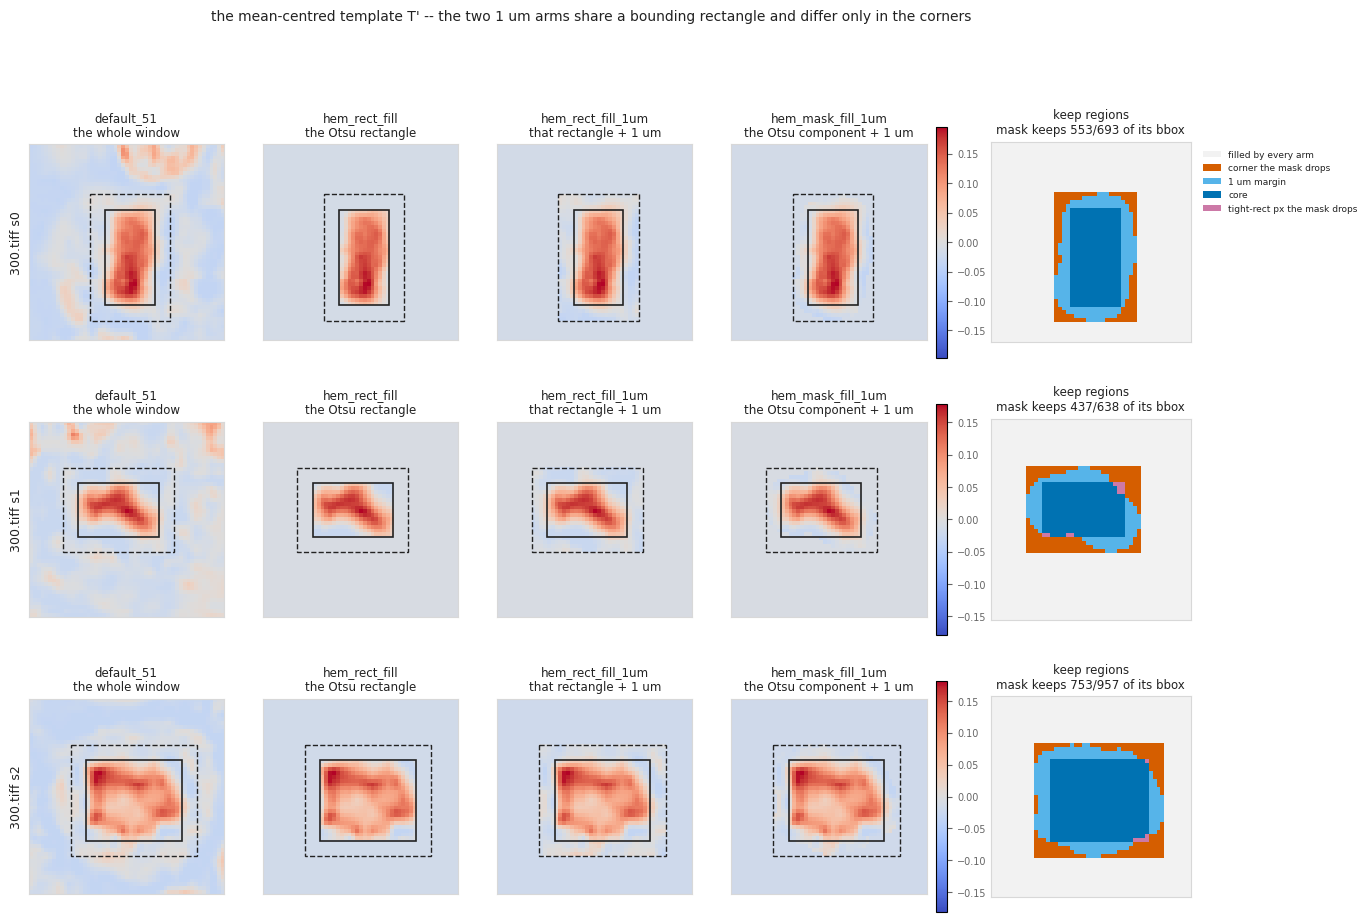

-> fillgeom6_templates.png


In [14]:
INK, MUTED, GRID = '#222222', '#666666', '#d8d8d8'


def recessive(ax):
    """
        Push an axes' frame and grid behind the data, the house style for every panel here.

        ax (matplotlib.axes.Axes): the axes to restyle.

        Returns None.
    """
    for side in ('top', 'right'):
        ax.spines[side].set_visible(False)
    for side in ('left', 'bottom'):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=8, length=3)
    ax.grid(True, color=GRID, linewidth=0.6, alpha=0.8)
    ax.set_axisbelow(True)


def keep_region_map(cut):
    """
        A categorical map of which arms keep which pixel, for one click.

        cut (dict): the click's cut_templates output.

        Returns np.ndarray: 0 filled by every arm, 1 corner the mask drops, 2 margin only the 1 um arms keep, 3 core kept by all three, 4 tight-rectangle pixel the mask drops.
    """
    rect, rectm, mask = cut['keeps']['hem_rect_fill'], cut['keeps']['hem_rect_fill_1um'], cut['keeps'][MASK_ARM]
    out = np.zeros((BASE_SIZE, BASE_SIZE), int)
    out[rectm & ~mask] = 1
    out[mask & ~rect] = 2
    out[mask & rect] = 3
    out[rect & ~mask] = 4
    return out


# Figure 1 -- the four templates as T', the only thing TM_CCOEFF correlates, plus the keep-region map that shows
# exactly where the two 1 um arms differ. T' is signed around 0, so the templates use a diverging scale with a
# neutral midpoint and symmetric limits shared across a row.
panel_clicks = [(INSPECT_ROI, s) for s in SEED_INDICES if (INSPECT_ROI, s) in CUTS][:3] or list(CUTS)[:3]
region_colors = ['#f2f2f2', '#D55E00', '#56B4E9', '#0072B2', '#CC79A7']
region_labels = ['filled by every arm', 'corner the mask drops', '1 um margin', 'core', 'tight-rect px the mask drops']
fig, axes = plt.subplots(len(panel_clicks), len(ARMS) + 1, figsize=(3.0 * (len(ARMS) + 1), 3.4 * len(panel_clicks)), squeeze=False)
for row, key in enumerate(panel_clicks):
    cut = CUTS[key]
    y0, y1, x0, x1 = cut['rect']
    my0, my1, mx0, mx1 = cut['rect_m']
    primes = {arm: cut['templates'][arm].astype(np.float64) - cut['templates'][arm].astype(np.float64).mean() for arm in ARMS}
    vmax = max(float(np.abs(p).max()) for p in primes.values())
    for col, arm in enumerate(ARMS):
        ax = axes[row][col]
        im = ax.imshow(primes[arm], cmap='coolwarm', vmin=-vmax, vmax=vmax)
        ax.add_patch(Rectangle((x0 - 0.5, y0 - 0.5), x1 - x0, y1 - y0, fill=False, edgecolor=INK, linewidth=1.2))
        ax.add_patch(Rectangle((mx0 - 0.5, my0 - 0.5), mx1 - mx0, my1 - my0, fill=False, edgecolor=INK, linewidth=1.0, linestyle='--'))
        ax.set_title(f'{arm}\n{ARM_KEEP[arm]}', fontsize=8.5, color=INK)
        ax.set_xticks([])
        ax.set_yticks([])
        for side in ax.spines.values():
            side.set_color(GRID)
    ax = axes[row][len(ARMS)]
    ax.imshow(keep_region_map(cut), cmap=plt.matplotlib.colors.ListedColormap(region_colors), vmin=-0.5, vmax=4.5, interpolation='nearest')
    ax.set_title(f"keep regions\nmask keeps {cut['n_kept'][MASK_ARM]}/{cut['n_kept']['hem_rect_fill_1um']} of its bbox", fontsize=8.5, color=INK)
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ax.spines.values():
        side.set_color(GRID)
    axes[row][0].set_ylabel(f'{key[0]} s{key[1]}', fontsize=9, color=INK)
    fig.colorbar(im, ax=axes[row][:len(ARMS)], fraction=0.016, pad=0.01).ax.tick_params(colors=MUTED, labelsize=7)
axes[0][len(ARMS)].legend(handles=[plt.matplotlib.patches.Patch(facecolor=c, label=l) for c, l in zip(region_colors, region_labels)], fontsize=6.5, frameon=False, labelcolor=INK, loc='upper left', bbox_to_anchor=(1.02, 1.0))
fig.suptitle("the mean-centred template T' -- the two 1 um arms share a bounding rectangle and differ only in the corners", fontsize=10, color=INK, y=0.995)
fig.savefig(FIG_PATHS['templates'], dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"-> {FIG_PATHS['templates']}")

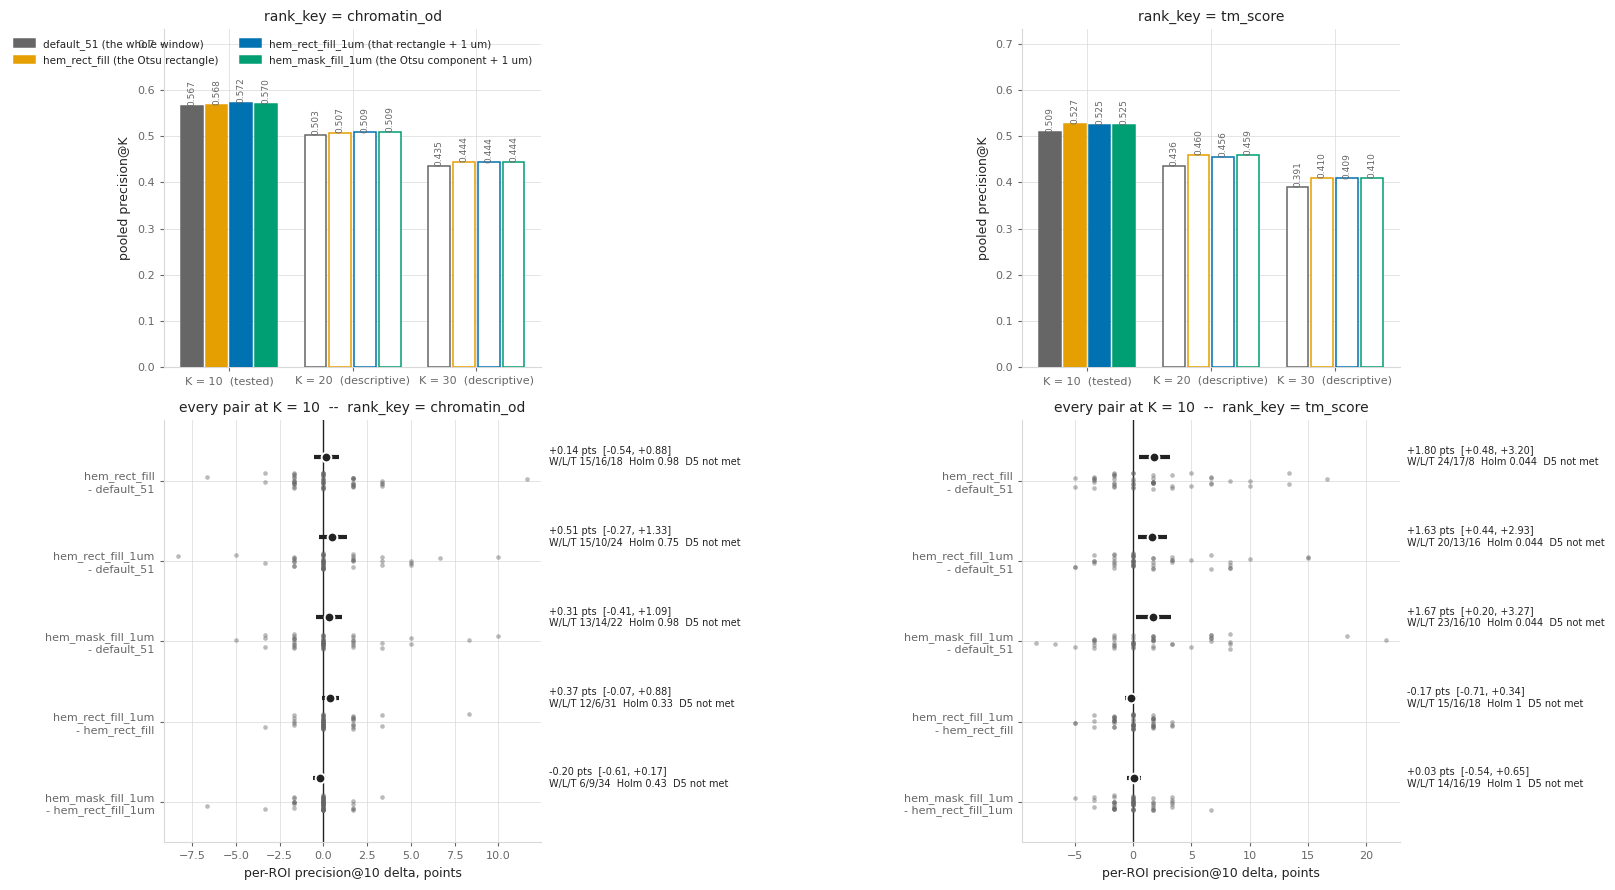

-> fillgeom6_precision.png


In [15]:
# Figure 2 -- the outcome at K = 10, one column per ranking axis. Top: pooled precision per arm (K = 20 and 30
# are shown hollow, as descriptive context, since neither is tested). Bottom: every pair's pooled delta with its
# bootstrap CI and the per-ROI deltas behind it.
fig, axes = plt.subplots(2, len(AXES), figsize=(8.0 * len(AXES), 9.0), gridspec_kw=dict(height_ratios=[1, 1.25]))
width = 0.2
for col, axis in enumerate(AXES):
    ax = axes[0][col]
    for i, arm in enumerate(ARMS):
        v = [POOLED.loc[(POOLED['rank_key'] == axis) & (POOLED['condition'] == arm) & (POOLED['K'] == k), 'precision_pooled'].iat[0] for k in BUDGETS]
        xs = np.arange(len(BUDGETS)) + (i - (len(ARMS) - 1) / 2) * width
        for x, val, k in zip(xs, v, BUDGETS):
            tested = k == TEST_K
            ax.bar([x], [val], width=width * 0.88, color=ARM_COLOR[arm] if tested else 'white', edgecolor=ARM_COLOR[arm], linewidth=1.1, zorder=3, label=f'{arm} ({ARM_KEEP[arm]})' if (tested and x == xs[BUDGETS.index(TEST_K)]) else None)
            ax.text(x, val + 0.004, f'{val:.3f}', ha='center', fontsize=6.5, color=MUTED, rotation=90)
    ax.set_xticks(range(len(BUDGETS)))
    ax.set_xticklabels([f'K = {k}' + ('  (tested)' if k == TEST_K else '  (descriptive)') for k in BUDGETS], fontsize=8.5, color=INK)
    ax.set_ylabel('pooled precision@K', fontsize=9, color=INK)
    ax.set_ylim(0, POOLED['precision_pooled'].max() * 1.28)
    ax.set_title(f'rank_key = {axis}', fontsize=10, color=INK)
    if col == 0:
        ax.legend(fontsize=7.5, frameon=False, ncol=2, labelcolor=INK, loc='upper right')
    recessive(ax)

    ax = axes[1][col]
    pair_labels = [f'{a} - {b}' for a, b in PAIRS]
    spread = []
    for p in pair_labels:
        st = DELTA_STATS[(DELTA_STATS['rank_key'] == axis) & (DELTA_STATS['pair'] == p)].iloc[0]
        spread += [100 * st['ci_low'], 100 * st['ci_high']] + list(100 * DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == axis) & (DELTA_PER_ROI['pair'] == p), 'delta_tp_sum'] / (N_CLICKS_PER_ROI * TEST_K))
    lo, hi = min(spread), max(spread)
    for j, p in enumerate(pair_labels):
        v = 100 * DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == axis) & (DELTA_PER_ROI['pair'] == p), 'delta_tp_sum'].to_numpy() / (N_CLICKS_PER_ROI * TEST_K)
        st = DELTA_STATS[(DELTA_STATS['rank_key'] == axis) & (DELTA_STATS['pair'] == p)].iloc[0]
        ax.scatter(v, np.full(len(v), j) + np.random.default_rng(j).uniform(-0.1, 0.1, len(v)), s=11, color=MUTED, alpha=0.45, linewidths=0, zorder=3)
        ax.plot([100 * st['ci_low'], 100 * st['ci_high']], [j - 0.3, j - 0.3], color=INK, linewidth=3, solid_capstyle='butt', zorder=4)
        ax.plot([100 * st['pooled_delta_precision']], [j - 0.3], marker='o', ms=7, color=INK, markeredgecolor='white', markeredgewidth=1.4, zorder=5)
        ax.annotate(f"{100 * st['pooled_delta_precision']:+.2f} pts  [{100 * st['ci_low']:+.2f}, {100 * st['ci_high']:+.2f}]\nW/L/T {int(st['wins'])}/{int(st['losses'])}/{int(st['ties'])}  Holm {st['holm_p']:.2g}  D5 {'met' if st['d5_bar_met'] else 'not met'}", xy=(1.02, j - 0.3), xycoords=('axes fraction', 'data'), fontsize=7.0, color=INK, va='center', ha='left', annotation_clip=False)
    ax.axvline(0, color=INK, linewidth=1.0, zorder=2)
    ax.set_yticks(range(len(pair_labels)))
    ax.set_yticklabels([p.replace(' - ', '\n  - ') for p in pair_labels], fontsize=7.5, color=INK)
    ax.set_xlabel(f'per-ROI precision@{TEST_K} delta, points', fontsize=9, color=INK)
    ax.set_xlim(lo - 0.04 * (hi - lo), hi + 0.04 * (hi - lo))
    ax.set_ylim(len(pair_labels) - 0.5, -0.75)
    ax.set_title(f'every pair at K = {TEST_K}  --  rank_key = {axis}', fontsize=10, color=INK)
    recessive(ax)

fig.tight_layout(w_pad=11.0)
fig.savefig(FIG_PATHS['precision'], dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"-> {FIG_PATHS['precision']}")

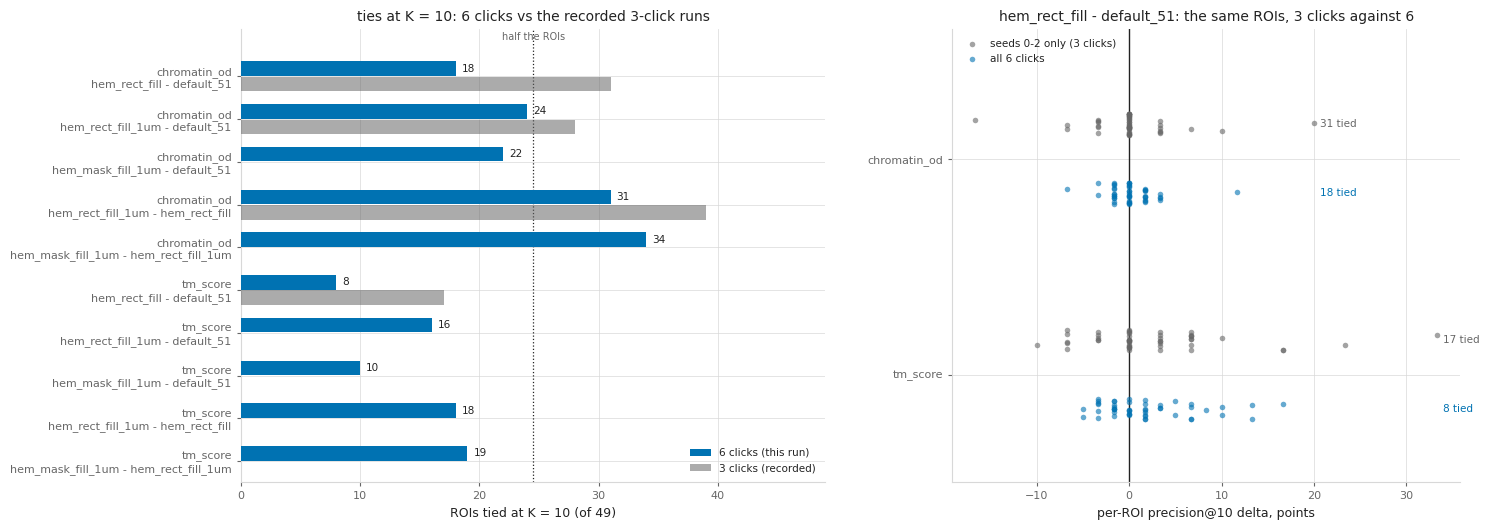

-> fillgeom6_granularity.png

notebook total: 45.3 min


In [16]:
# Figure 3 -- the granularity this run bought. Left: ties per pair at 6 clicks against the 3-click measurement of
# the same contrast, where one exists. Right: the per-ROI delta distribution for the one contrast with a 3-click
# baseline on both axes, at both click counts -- the 6-click step is half the 3-click step, so fewer ROIs sit on 0.
fig, axes = plt.subplots(1, 2, figsize=(15.0, 5.4), gridspec_kw=dict(width_ratios=[1.15, 1]))

ax = axes[0]
labels = [f"{r.rank_key}\n{r.pair}" for r in TIE.itertuples()]
ys = np.arange(len(TIE))
ax.barh(ys - 0.18, TIE['ties'], height=0.34, color='#0072B2', zorder=3, label=f'{N_CLICKS_PER_ROI} clicks (this run)')
has_base = TIE['ties_3click'] != ''
ax.barh(ys[has_base.to_numpy()] + 0.18, [int(v.split('/')[0]) for v in TIE.loc[has_base, 'ties_3click']], height=0.34, color=MUTED, alpha=0.55, zorder=3, label='3 clicks (recorded)')
for j, r in enumerate(TIE.itertuples()):
    ax.text(r.ties + 0.5, j - 0.18, f'{r.ties}', va='center', fontsize=7.5, color=INK)
ax.axvline(N_ROIS / 2, color=INK, linewidth=0.9, linestyle=':', zorder=2)
ax.text(N_ROIS / 2, -0.85, 'half the ROIs', fontsize=7, color=MUTED, ha='center')
ax.set_yticks(ys)
ax.set_yticklabels(labels, fontsize=7, color=INK)
ax.set_xlabel(f'ROIs tied at K = {TEST_K} (of {N_ROIS})', fontsize=9, color=INK)
ax.set_xlim(0, N_ROIS)
ax.set_ylim(len(TIE) - 0.5, -1.1)
ax.set_title(f'ties at K = {TEST_K}: {N_CLICKS_PER_ROI} clicks vs the recorded 3-click runs', fontsize=10, color=INK)
ax.legend(fontsize=7.5, frameon=False, labelcolor=INK, loc='lower right')
recessive(ax)

ax = axes[1]
REPRO = 'hem_rect_fill - default_51'
for j, axis in enumerate(AXES):
    v = DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == axis) & (DELTA_PER_ROI['pair'] == REPRO), 'delta_tp_sum'].to_numpy()
    v6 = 100 * v / (N_CLICKS_PER_ROI * TEST_K)
    v3 = 100 * DELTA_PER_ROI.loc[(DELTA_PER_ROI['rank_key'] == axis) & (DELTA_PER_ROI['pair'] == REPRO), 'delta_tp_recorded_seeds'].to_numpy() / (len(RECORDED_SEEDS) * TEST_K)
    for off, vals, color, tag in ((-0.16, v3, MUTED, 'seeds 0-2 only (3 clicks)'), (0.16, v6, '#0072B2', f'all {N_CLICKS_PER_ROI} clicks')):
        ax.scatter(vals, np.full(len(vals), j + off) + np.random.default_rng(j).uniform(-0.05, 0.05, len(vals)), s=16, color=color, alpha=0.6, linewidths=0, zorder=3, label=tag if j == 0 else None)
        ax.text(max(v6.max(), v3.max()) + 0.6, j + off, f'{int((vals == 0).sum())} tied', fontsize=7.5, color=color, va='center')
ax.axvline(0, color=INK, linewidth=1.0, zorder=2)
ax.set_yticks(range(len(AXES)))
ax.set_yticklabels(list(AXES), fontsize=9, color=INK)
ax.set_xlabel(f'per-ROI precision@{TEST_K} delta, points', fontsize=9, color=INK)
ax.set_ylim(len(AXES) - 0.5, -0.6)
ax.set_title(f'{REPRO}: the same ROIs, 3 clicks against {N_CLICKS_PER_ROI}', fontsize=10, color=INK)
ax.legend(fontsize=7.5, frameon=False, labelcolor=INK, loc='upper left')
recessive(ax)

fig.tight_layout(w_pad=3.0)
fig.savefig(FIG_PATHS['granularity'], dpi=130, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"-> {FIG_PATHS['granularity']}")
print(f'\nnotebook total: {(time.time() - NB_T0) / 60:.1f} min')

## Reading the result

**K = 10 resolved.** At `tm_score` all three surround-fill arms beat `default_51`, every bootstrap CI excluding 0
and every Holm-adjusted p below 0.05; at `chromatin_od` nothing separates from `default_51`. Neither secondary
contrast separates on either axis. **No contrast meets the D5 bar**, because none moves a majority of all 49
ROIs -- the closest is 24 of 49.

`tm_score` carries the inference. The mass term these templates are built around is nearly the same statistic as
the `chromatin_od` ranker, so that axis flatters any arm carrying one; it is reported, not read as a replication.

Pooled precision@10, 49 ROIs x 6 clicks (K = 20 and K = 30 are in the CSVs as descriptive columns and are quoted
nowhere here -- only K = 10 was tested):

| arm | keep region | `chromatin_od` | `tm_score` |
|---|---|---|---|
| `default_51` | the whole window | 0.5667 | 0.5085 |
| `hem_rect_fill` | the Otsu rectangle | 0.5680 | **0.5265** |
| `hem_rect_fill_1um` | that rectangle + 1 um | 0.5718 | 0.5248 |
| `hem_mask_fill_1um` | the Otsu component + 1 um | 0.5697 | 0.5252 |

### Primary -- does flattening the surround help? At `tm_score`, yes

All three arms land within 0.2 points of each other, and all three clear Holm at 0.0436 (the family's three raw
p-values are 0.0145, 0.0157, 0.0415; Holm ties them at the largest adjusted value).

| pair | delta | boot CI | t CI | W/L/T | nonzero | exact p | Holm | D5 |
|---|---|---|---|---|---|---|---|---|
| `hem_rect_fill - default_51` | **+1.80** | [+0.48, +3.20] | [+0.38, +3.22] | 24/17/8 | 41 | 0.0145 | 0.0436 | **not met** (24/49) |
| `hem_rect_fill_1um - default_51` | **+1.63** | [+0.44, +2.93] | [+0.33, +2.93] | 20/13/16 | 33 | 0.0157 | 0.0436 | **not met** (20/49) |
| `hem_mask_fill_1um - default_51` | **+1.67** | [+0.20, +3.27] | [+0.08, +3.25] | 23/16/10 | 39 | 0.0415 | 0.0436 | **not met** (23/49) |

Every one of the three excludes 0 on all 20 further bootstrap seeds, so none is a seeding artefact -- but they
are not equally secure. The closest bound to 0 is +0.44 points for `hem_rect_fill` and +0.41 for
`hem_rect_fill_1um`, against **+0.17 for `hem_mask_fill_1um`**. The mask arm is the marginal one of the three,
and it is also the only arm with no external reference of any kind, so it should be weighted accordingly.

**Why D5 fails while the CI holds.** The bar asks for a bootstrap CI excluding 0 **and** a majority of all 49 ROIs
moving in the delta's direction. The best arm wins on 24 ROIs and loses on 17 -- one ROI short of a
majority. The gain is real in the pooled sense, but it is a modest edge with substantial per-ROI disagreement,
not something that happens on most ROIs.

**At `chromatin_od`, no difference is detected.** `hem_rect_fill - default_51` +0.14 [-0.54, +0.88] (t
[-0.59, +0.87], W/L/T 15/16/18, 31 nonzero, exact p 0.795, Holm 0.978); `hem_rect_fill_1um - default_51`
+0.51 [-0.27, +1.33] (15/10/24, 25 nonzero, p 0.250, Holm 0.751); `hem_mask_fill_1um - default_51`
+0.31 [-0.41, +1.09] (13/14/22, 27 nonzero, p 0.489, Holm 0.978). The CIs are the bound -- roughly +/-1 point.
**No equivalence is claimed.**

### Secondary -- which ingredient is doing the work? Neither

| pair | axis | delta | boot CI | t CI | W/L/T | nonzero | exact p | Holm |
|---|---|---|---|---|---|---|---|---|
| `hem_rect_fill_1um - hem_rect_fill` | `tm_score` | -0.17 | [-0.71, +0.34] | [-0.72, +0.38] | 15/16/18 | 31 | 0.625 | 1.00 |
| `hem_rect_fill_1um - hem_rect_fill` | `chromatin_od` | +0.37 | [-0.07, +0.88] | [-0.11, +0.86] | 12/6/31 | 18 | 0.167 | 0.334 |
| `hem_mask_fill_1um - hem_rect_fill_1um` | `tm_score` | +0.03 | [-0.54, +0.65] | [-0.57, +0.64] | 14/16/19 | 30 | 1.00 | 1.00 |
| `hem_mask_fill_1um - hem_rect_fill_1um` | `chromatin_od` | -0.20 | [-0.61, +0.17] | [-0.61, +0.21] | 6/9/34 | 15 | 0.433 | 0.433 |

**The 1 um margin adds nothing**, and **dropping the rectangle's corners adds nothing.** Both CIs are under a
point wide on either side. Since the corner contrast holds the padding and the bounding rectangle fixed and
varies only keep-region **shape**, this is as clean a null on shape as this design can produce -- the mask keeps a
median 70% of its bounding rectangle, so the arms really did differ by roughly 30% of the kept area.

**The 3-click margin result does not survive.** `hem_rect_fill_1um - hem_rect_fill` at `chromatin_od` was the one
contrast that had been K = 10-only: +0.75 points [+0.27, +1.36] pre-D11, with 39 of 49 ROIs tied. Read on this
run's own seeds 0-2 it reproduces (+0.82 [+0.27, +1.50], exact p 0.0156); read on all 6 clicks it is
+0.37 [-0.07, +0.88], exact p 0.167. The extra clicks moved its ties from 39/49 to 31/49 and its nonzero ROIs
from 10 to 18, and the effect did not hold up. **That result was a granularity artefact.**

### The tie report -- what the extra clicks bought

Ties fell on every contrast that also had a 3-click measurement, and `n_nonzero` rose on all of them:

| axis | pair | ties 3 -> 6 clicks | nonzero 3 -> 6 | floor 3 -> 6 |
|---|---|---|---|---|
| `tm_score` | `hem_rect_fill - default_51` | 17/49 -> **8/49** | 32 -> 41 | 4.7e-10 -> 9.1e-13 |
| `chromatin_od` | `hem_rect_fill - default_51` | 31/49 -> **18/49** | 18 -> 31 | 7.6e-06 -> 9.3e-10 |
| `chromatin_od` | `hem_rect_fill_1um - default_51` | 28/49 -> 24/49 | 21 -> 25 | 9.5e-07 -> 6.0e-08 |
| `chromatin_od` | `hem_rect_fill_1um - hem_rect_fill` | 39/49 -> 31/49 | 10 -> 18 | 2.0e-03 -> 7.6e-06 |

**No row is floor-blocked.** Every one of the 10 tests has a Holm-adjusted floor below 1.3e-04, so each could have
reached significance at a large enough effect size. Every null above is a real null, not a row that bounds nothing.

**The point estimate shrank as the measurement sharpened.** For the headline contrast at `tm_score`, reading this
same run on seeds 0-2 alone gives +2.45 points [+0.48, +4.69] with 17 ties -- reproducing the recorded 3-click
number exactly -- while all 6 clicks give +1.80 [+0.48, +3.20] with 8 ties. Same ROIs, same arms, same pipeline;
only the click count differs (`delta_per_roi.csv` carries both columns, and Figure 3 plots them). The 3-click
estimate was optimistic by about a third, and the narrower interval is what converts Holm 0.124 into Holm 0.0436.

### One structural tie, not a granularity tie

On `403.tiff` seed 5 the Otsu rectangle already spans the window's full height, so growing it by 4 px covers the
whole window and `hem_rect_fill_1um` is byte-identical to `default_51` there. That click contributes a structural
0 to `hem_rect_fill_1um - default_51` -- 1 click of 294, on 1 ROI, and **0 ROIs are forced ties**, since that
ROI's other 5 clicks still move. It dilutes that one contrast rather than inflating it. No other arm or pair is
affected: the tight rectangle never covers the window (max 2346 of 2601 px), and the dilated mask never does
either (minimum 696 pixels left outside it).

### What this means

**Flattening the seed template's surround is worth about 1.7 points of precision@10 on the axis where candidate
generation and ranking do not share a statistic** -- and it does not matter which of the three keep-regions does
the flattening. The tight Otsu rectangle already captures the whole effect; padding it by 1 um and following the
component's actual outline instead of its bounding box each add nothing measurable.

For the product: the decision worth making is **flatten or don't**. Refining *which* pixels to keep is tuning
below this measurement's resolution, and this run had the granularity to say so -- these are real nulls with
floors far below 0.05, not unresolved rows.

The gain is also not something a pathologist would see on most ROIs: 24 of 49 improve, 17 get worse, 8 are
unchanged. That is why D5 is not met, and the W/L/T should be quoted alongside the pooled number rather than
behind it.

### Standing caveats

- The 294 clicks are the 49-ROI joint gate's, so every click is one where **both** Otsu gates accept and a kept
  rectangle exists by construction. Conditioning on the hem gate is intrinsic to these arms; conditioning on the
  *gray* gate is inherited baggage.
- One channel, one margin (1 um = 4 px on every ROI), one component definition.
- `max_peaks` binds at 100 on all 2352 rows, so every arm is compared at a saturated candidate pool.
- The two axes are two families and rank the same detections. `tm_score` resolving where `chromatin_od` does not
  is **not** a contradiction and **not** a replication -- it is the ranker-alignment confound behaving as
  expected.
- Only K = 10 was tested. TP@20 and TP@30 are in `per_run.csv` as descriptive columns and support no claim here.